# Social Media Addiction and Relationships Research Paper

Author: Suchi Patel

Institution: George Washington University

Course: Introduction to Health Data Science

Date: [Submission Date] 


# Python Setup 

In [21]:
# Import packages for numerical computation, statistics, and plotting, and data wrangling
import sys
import numpy as np
import pandas as pd
import scipy 
from scipy import stats
import matplotlib 
import seaborn as sns
import matplotlib.pyplot as plt
print('Python (sys.verison.split()[0])')
print('Numpy (np.__version__)')
print('Pandas (pd.__version__)')
print('Scipy (scipy.__version__)')
print('Matplotlib (matplotlib.__version__)')
print('Seaborn (sns.__version__)')

Python (sys.verison.split()[0])
Numpy (np.__version__)
Pandas (pd.__version__)
Scipy (scipy.__version__)
Matplotlib (matplotlib.__version__)
Seaborn (sns.__version__)


In [22]:
# Change seaborn and matplotlib to dark style
sns.set_style('dark')

In [50]:
# Import the required packages to create a linear regression model
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

In [51]:
# Import the required packages for a logistic regression model
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

In [52]:
# Import the required packages to create a random forest model
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

In [2]:
%config InlineBackend.figure_format = 'retina'

In [57]:
!kaggle datasets list -s addiction

ref                                                            title                                                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
-------------------------------------------------------------  --------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
khushikyad001/cigarettes-and-alcohol-addiction                 Cigarettes & Alcohol Addiction                          134636  2025-05-15 14:03:28.250000           3543         50                1  
jayjoshi37/smartphone-usage-and-addiction-prediction           Smartphone Usage & Addiction Prediction                 182295  2026-02-19 05:25:36.980000           1815         36                1  
zahranusratt/student-social-media-addiction-analysis-dataset   Student Social Media Addiction Analysis Dataset           7851  2026-01-22 04:02:08.347000           3272         79                1  
sumed

In [78]:
import pandas as pd

df = pd.read_csv('/Users/suchipatel/Downloads/Students Social Media Addiction 2.csv')
df.head()

,Student_ID,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Relationship_Status,Conflicts_Over_Social_Media,Addicted_Score
0,1,19,Female,Undergraduate,Bangladesh,5.2,Instagram,Yes,6.5,6,In Relationship,3,8
1,2,22,Male,Graduate,India,2.1,Twitter,No,7.5,8,Single,0,3
2,3,20,Female,Undergraduate,USA,6.0,TikTok,Yes,5.0,5,Complicated,4,9
3,4,18,Male,High School,UK,3.0,YouTube,No,7.0,7,Single,1,4
4,5,21,Male,Graduate,Canada,4.5,Facebook,Yes,6.0,6,In Relationship,2,7


#### Indicate code using back ticks for example df

We perform data vertification on the data:

1. Shape

2. Information

3. Return first five rows of data

# Introduction

Social media has become deeply embedded in daily life, especially among adolescents and young adults, transforming how people initiate, maintain, and end relationships.  At the same time, health organizations and researchers increasingly describe “problematic” or addictive social media use as a growing public health concern because it is linked to poorer mental health, sleep disruption, and conflicts in offline life.  Young people report that social media helps them feel more connected and supported, yet excessive or compulsive use may displace face‑to‑face interaction and strain important relationships with family, friends, and romantic partners.  Understanding how social media addiction relates specifically to relationship quality among students is therefore important for informing prevention and intervention efforts in schools and universities. [Matthew, L]( https://doi.org/10.1136/bmj.q2102) , [Abderrahman, K](https://doi.org/10.7759/cureus.42990) , [Bernadette, P](https://doi.org/10.3390/healthcare13212763)

Existing research shows that heavy and problematic social media use is associated with higher levels of depression, anxiety, and poorer overall well‑being in adolescents and young adults, although social media can also provide social support and a sense of community.  Studies focusing on romantic relationships have found that social media–related jealousy, electronic partner surveillance, and “phubbing” (ignoring a partner to look at one’s phone) are linked to lower relationship satisfaction over time.  Research also suggests that social media addiction is negatively correlated with relationship satisfaction and may mediate the impact of unmet psychological needs on how satisfied people feel in their relationships.  However, there are still important gaps: many studies rely on small or non‑student samples, focus on either mental health or romantic relationships (but not broader relationship networks), and pay limited attention to how the intensity of social media addiction relates simultaneously to multiple types of relationships (family, friends, and romantic partners) in diverse student populations. [Abderrahman, K](https://doi.org/10.7759/cureus.42990) , [Bernadette, P](https://doi.org/10.3390/healthcare13212763) , [Sarafina, M](https://doi.org/10.1111/jmft.70074) , [Hüseyin, K](https://doi.org/10.3389/fpsyg.2024.1291638) 



The aim of this study is to examine how social media addiction is associated with the quality of close relationships among students using the “Student Social Media & Relationships” dataset, which includes anonymized survey responses on social‑media behaviors and relationship dynamics across academic levels and countries.  Specifically, this research will (1) describe patterns of social media addiction among students, (2) assess how different levels of addiction relate to self‑reported relationship quality with family, friends, and romantic partners, and (3) explore whether these associations vary by demographic factors such as age, gender, and academic level.  By addressing these objectives, the study seeks to fill the identified gaps by providing quantitative evidence on the link between social media addiction and multiple relationship domains within a large, diverse student sample, thereby informing targeted public health and campus‑based strategies to support healthier social media use.  A central research question guiding this work is: “To what extent is higher social media addiction associated with lower relationship quality among students?” with the hypothesis that students with higher addiction scores will report poorer relationship outcomes than those with lower or non‑addictive levels of use. [Bernadette, P](https://doi.org/10.3390/healthcare13212763), [Hüseyin, K](https://doi.org/10.3389/fpsyg.2024.1291638),[Shamim, A](https://www.kaggle.com/code/adilshamim8/social-media-addiction-among-students),[Limb, M](doi: https://doi.org/10.1136/bmj.q2102), [Abderrahman, K](https://doi.org/10.7759/cureus.42990) 



next paragraph here, if there is any numbers in the paragraphs then do this: $3-4$%

<h2>Background<h2>

Research on social media use has expanded rapidly over the last decade, reflecting its deep integration into everyday life and its emerging relevance as a public health issue. Problematic or “addictive” social networking site (SNS) use has been associated with higher levels of depression, anxiety, stress, and loneliness, as well as poorer sleep and overall well‑being in adolescents and adults. These patterns have led some researchers to argue that social media addiction should be viewed as a behavioral addiction, characterized by compulsive use, loss of control, and continued engagement despite negative consequences in offline life. At the same time, social media can provide social support, information, and a sense of belonging, illustrating that its health effects are not uniformly harmful but depend on how, how much, and for what purposes it is used. Because close relationships and social support are powerful determinants of mental and physical health, understanding how problematic social media use affects relationship quality has become an important focus within public health and behavioral science. [Weinstein, A](https://doi.org/10.3389/fpsyt.2022.1106004), [Chadha, L](https://doi.org/10.4103/jfmpc.jfmpc_1808_24) , [Wright, K](https://doi.org/10.3389/fcomm.2016.00010)

A central concept in this area is “problematic social media use” or “social media addiction,” which describes excessive, poorly controlled use that interferes with daily activities, mental health, and interpersonal functioning. Theoretical models draw on general addiction frameworks and self‑determination theory, suggesting that individuals may turn to social media to meet unmet psychological needs for connection, belonging, power, and autonomy, but overreliance on digital interaction can paradoxically undermine those same needs. Fear of missing out (FoMO), social comparison processes, and reinforcement from likes and comments have been identified as mechanisms that maintain compulsive checking behaviors and increase vulnerability to problematic use. Studies also link problematic SNS use with “peer phubbing” (ignoring others face‑to‑face to focus on one’s phone), which correlates with loneliness and social anxiety, suggesting that digital preoccupation can erode the quality of in‑person interactions. These mechanisms are particularly concerning in adolescence and young adulthood, when social identities and relationship patterns are still forming and when lifetime trajectories of health behaviors often begin. [Wright, K](https://doi.org/10.3389/fcomm.2016.00010) , [Karaman, H](https://doi.org/10.3389/fpsyg.2024.1291638) ,  [Weinstein, A](https://doi.org/10.3389/fpsyt.2022.1106004)


A growing body of work focuses specifically on social media addiction and romantic relationship functioning. One recent university‑based study found that social media addiction was significantly positively correlated with phubbing and significantly negatively correlated with relationship satisfaction, indicating that higher addictive use and more frequent partner‑ignoring behaviors are associated with poorer romantic relationship outcomes. In this study, social media addiction and phubbing jointly mediated the association between satisfaction of basic psychological needs in romantic relationships (such as love/belonging, power, and freedom) and relationship satisfaction, suggesting that when needs are not met in a relationship, individuals may increasingly turn to social media, which in turn contributes to more phubbing and lower satisfaction. Other work highlights related phenomena such as social media–related jealousy, cyber‑infidelity, and electronic partner surveillance, all of which can erode trust and contribute to conflict. Together, these findings support the idea that problematic social media use not only reflects individual vulnerabilities but also operates within relationship dynamics, where it can both respond to and worsen existing tensions. [Karaman, H](https://doi.org/10.3389/fpsyg.2024.1291638) , [Elyse, B](https://carraratreatment.com/social-medias-impact-on-interpersonal-relationships/) 


Beyond romantic partnerships, there is evidence that problematic social media use can strain broader interpersonal relationships with peers and family. Reviews of problematic SNS use describe links with social comparison, envy, and perceived social exclusion, which can increase interpersonal conflict and decrease perceived social support. Research on social networks and health shows that negative aspects of relationships—such as ongoing conflict, role strain, or lack of responsiveness—are associated with increased stress and worse health outcomes, reinforcing the public health importance of maintaining supportive, high‑quality relationships. Excessive device use during shared time can signal inattention or disinterest, and qualitative accounts suggest that family members and friends may perceive heavy social media engagement as disrespectful or distancing, contributing to relational dissatisfaction. However, systematic data directly linking measured social media addiction scores to perceived quality of relationships with family and friends, especially in student populations across different educational levels and countries, remain comparatively limited. [Elyse, B](https://carraratreatment.com/social-medias-impact-on-interpersonal-relationships/), [Weinstein, A](https://doi.org/10.3389/fpsyt.2022.1106004), [Wright, K](https://doi.org/10.3389/fcomm.2016.00010)


From a public health perspective, these patterns are significant because interpersonal relationships are key determinants of both mental and physical health across the lifespan. Strong, supportive relationships buffer stress, reduce the risk of depression, and are associated with better cardiovascular, immune, and mortality outcomes, whereas chronic relational conflict and isolation predict poorer health. Problematic social media use intersects with these pathways by potentially replacing in‑person contact, increasing conflict through jealousy or phubbing, and undermining feelings of closeness and support in romantic, peer, and family relationships. At the same time, young people are among the heaviest social media users, and universities and schools increasingly recognize the need to address digital behaviors as part of mental‑health and well‑being initiatives. Understanding how gradients of social media addiction relate to multiple relationship domains in student populations can therefore inform campus‑based prevention programs, digital wellness campaigns, and counseling interventions that target both individual behavior and relationship skills. [Karaman, H](https://doi.org/10.3389/fpsyg.2024.1291638), [Weinstein, A](https://doi.org/10.3389/fpsyt.2022.1106004), [Wright, K](https://doi.org/10.3389/fcomm.2016.00010), [Elyse, B](https://carraratreatment.com/social-medias-impact-on-interpersonal-relationships/), [Karaman, H](https://doi.org/10.3389/fpsyg.2024.1291638)


Despite the rapid growth of this literature, several gaps remain that justify the present study. Many existing studies focus narrowly on romantic relationships, leaving less known about how social media addiction concurrently influences relationships with family and friends, which are also central to student well‑being. Samples are often drawn from single institutions or specific cultural contexts, limiting generalizability, and some rely on small sample sizes or cross‑sectional designs that reduce the ability to explore subgroup differences. There is also limited use of datasets that combine detailed measures of social media addiction with self‑reported indicators of relationship closeness or satisfaction across different relationship types in diverse student samples. By analyzing the “Students’ Social Media Addiction vs Relationships” dataset, which includes information on social media addiction and various relationship dimensions among students, the current research addresses these gaps by providing quantitative evidence on how levels of social media addiction relate to relationship outcomes across multiple relational domains. This work contributes to the broader public health literature by clarifying which subsets of students may be most at risk for relationship strain linked to social media addiction and by providing data that can guide targeted, relationship‑focused digital health interventions. [Karaman, H](https://doi.org/10.3389/fpsyg.2024.1291638), [Shamim, A](https://www.kaggle.com/code/adilshamim8/social-media-addiction-among-students), [Weinstein, A](https://doi.org/10.3389/fpsyt.2022.1106004)


# Methods

*** explain where you got the data. something about it, and what the columns mean ^^^

This study uses a cross-sectional survey design based on a publicly available Kaggle dataset titled “Students’ Social Media Addiction vs Relationships.” A cross-sectional design is appropriate because the data capture students’ social media habits and relationship-related responses at a single point in time rather than following participants over time. The target population appears to be students, with responses collected from a diverse sample that includes different academic levels and demographic backgrounds. Because the dataset is pre-existing and de-identified, the study does not involve direct recruitment by the researcher; instead, it uses secondary data from the Kaggle repository.



The exact sample size, recruitment strategy, and inclusion/exclusion criteria should be reported based on the dataset documentation if available. In general, the inclusion criteria for this analysis are students with complete responses for the variables relevant to social media addiction and relationship measures. Records with substantial missing data on key variables may be excluded from analysis to preserve data quality. If the dataset contains responses from non-students or duplicate entries, those would also be excluded if identified during data cleaning.



The data were collected using survey/questionnaire items rather than interviews or observations. The questionnaire includes variables related to social media addiction and relationship factors, making it a quantitative dataset suitable for statistical analysis. Since the study is entirely quantitative, there is no qualitative component. Social media addiction and relationship outcomes are measured through self-reported responses, which are then analyzed to examine associations between levels of social media use and relationship quality.



### Data Import and Vertification. This section goes above Exploratory Analysis

In [53]:
!export KAGGLE_API_TOKEN=KGAT_817f7a413b03633dca9032bd4d091311

In [54]:
import os
os.environ["KAGGLE_USERNAME"] = "your_kaggle_username"
os.environ["KAGGLE_KEY"] = "your_kaggle_key"

# Results

** a bunch fo code and plots

In [8]:
The data are contained in a comma-seperated values file, which is imported below and assigned to the variable df


SyntaxError: invalid syntax (1788015226.py, line 1)

In [ ]:
# import the file.csv file and assign it to the variable df

In [10]:
# return the shape of df
df.shape

NameError: name 'df' is not defined

The data set contains information about 393 subject.

In [11]:
# return the first five rows of data 
df.head()

NameError: name 'df' is not defined

### Exploratory Data Analysis

1. Student Demographics

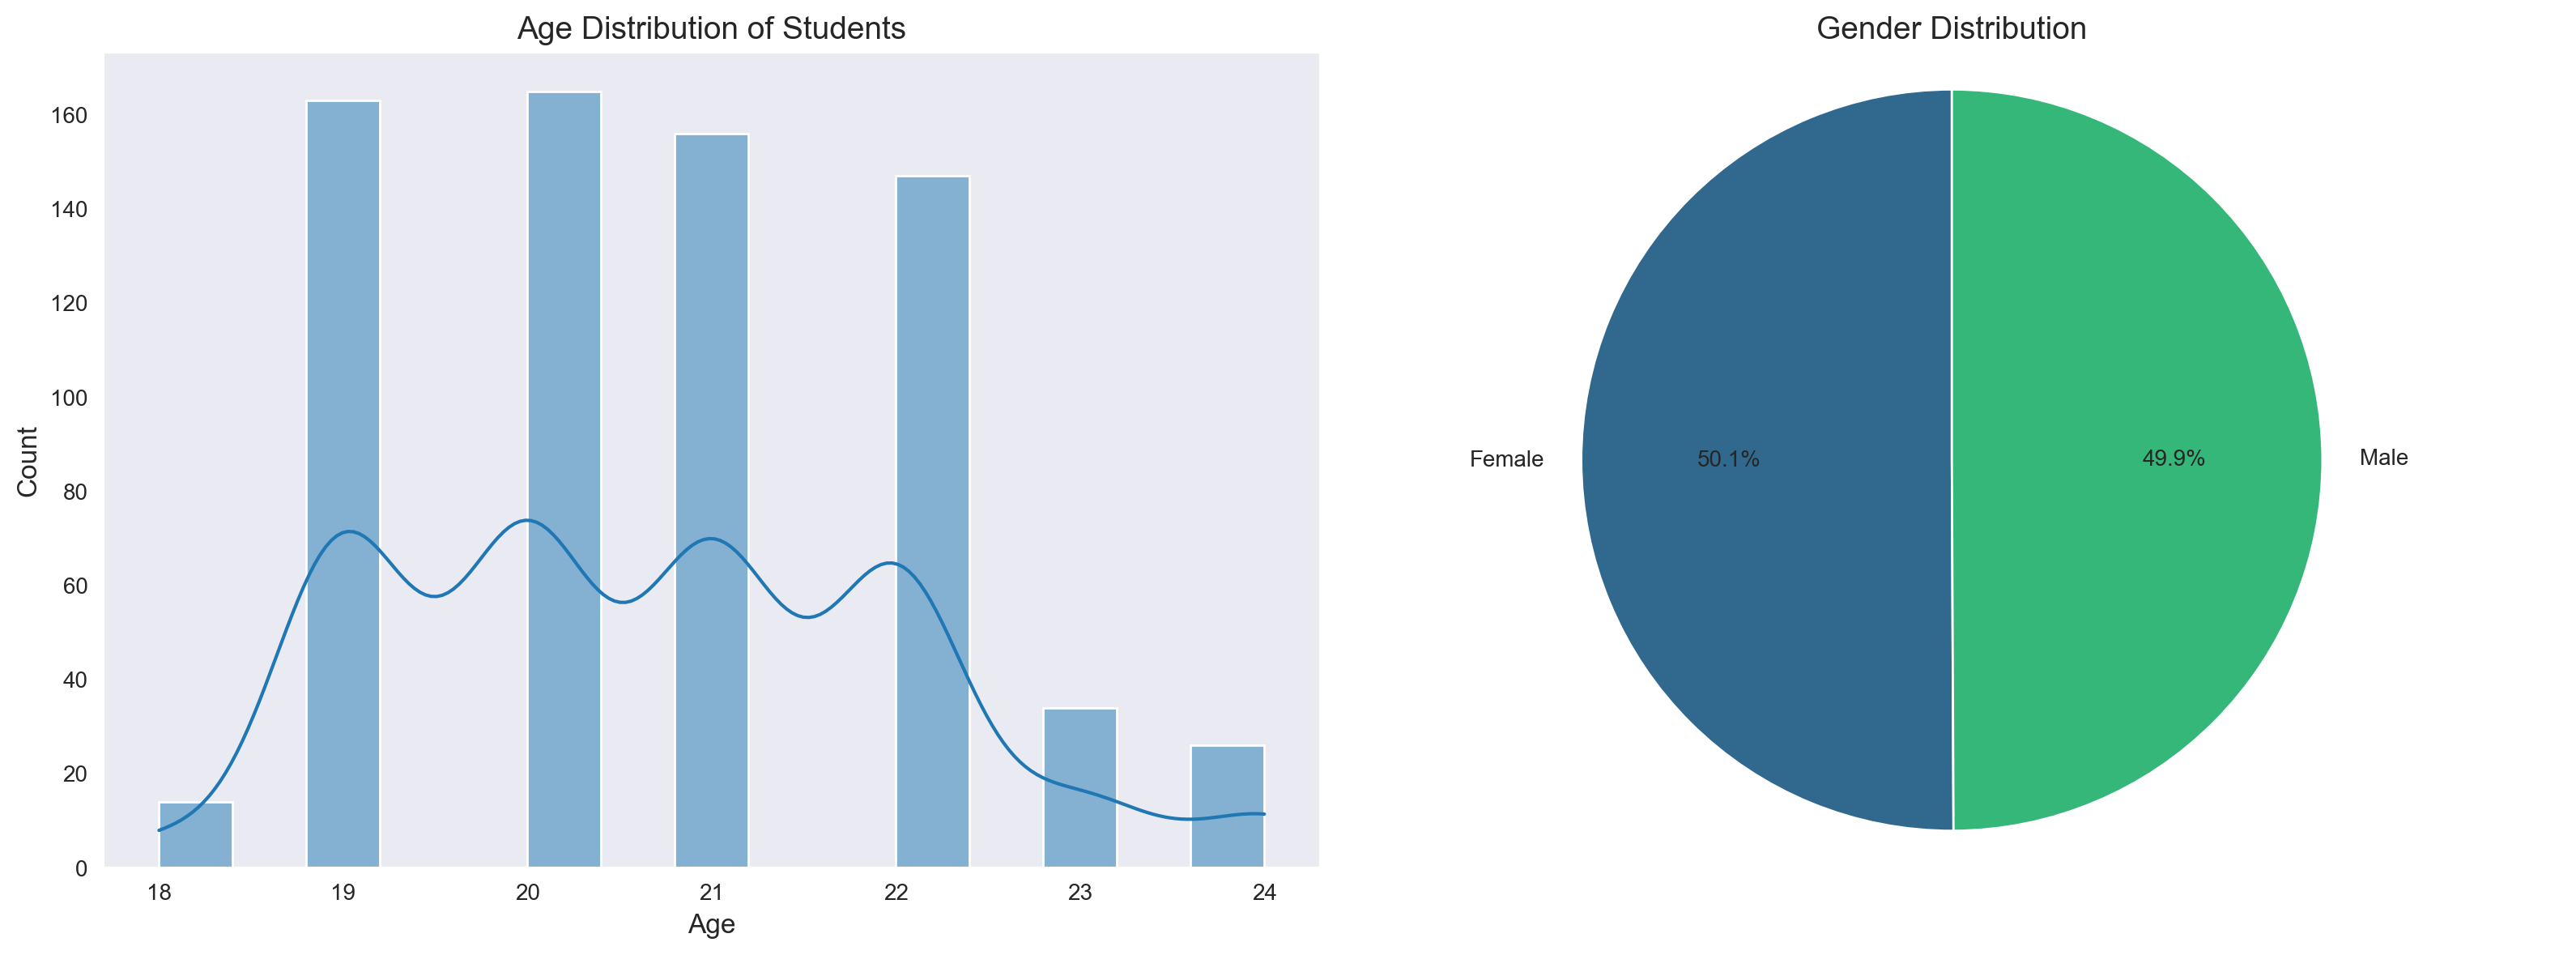

In [79]:
#### Age and Gender Distribution
plt.figure(figsize=(16, 6))

# Age distribution
plt.subplot(1, 2, 1)
sns.histplot(df['Age'], kde=True, bins=15)
plt.title('Age Distribution of Students', fontsize=14)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Count', fontsize=12)

# Gender distribution
plt.subplot(1, 2, 2)
gender_counts = df['Gender'].value_counts()
plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('viridis', len(gender_counts)))
plt.title('Gender Distribution', fontsize=14)
plt.axis('equal')

plt.tight_layout()
plt.show()

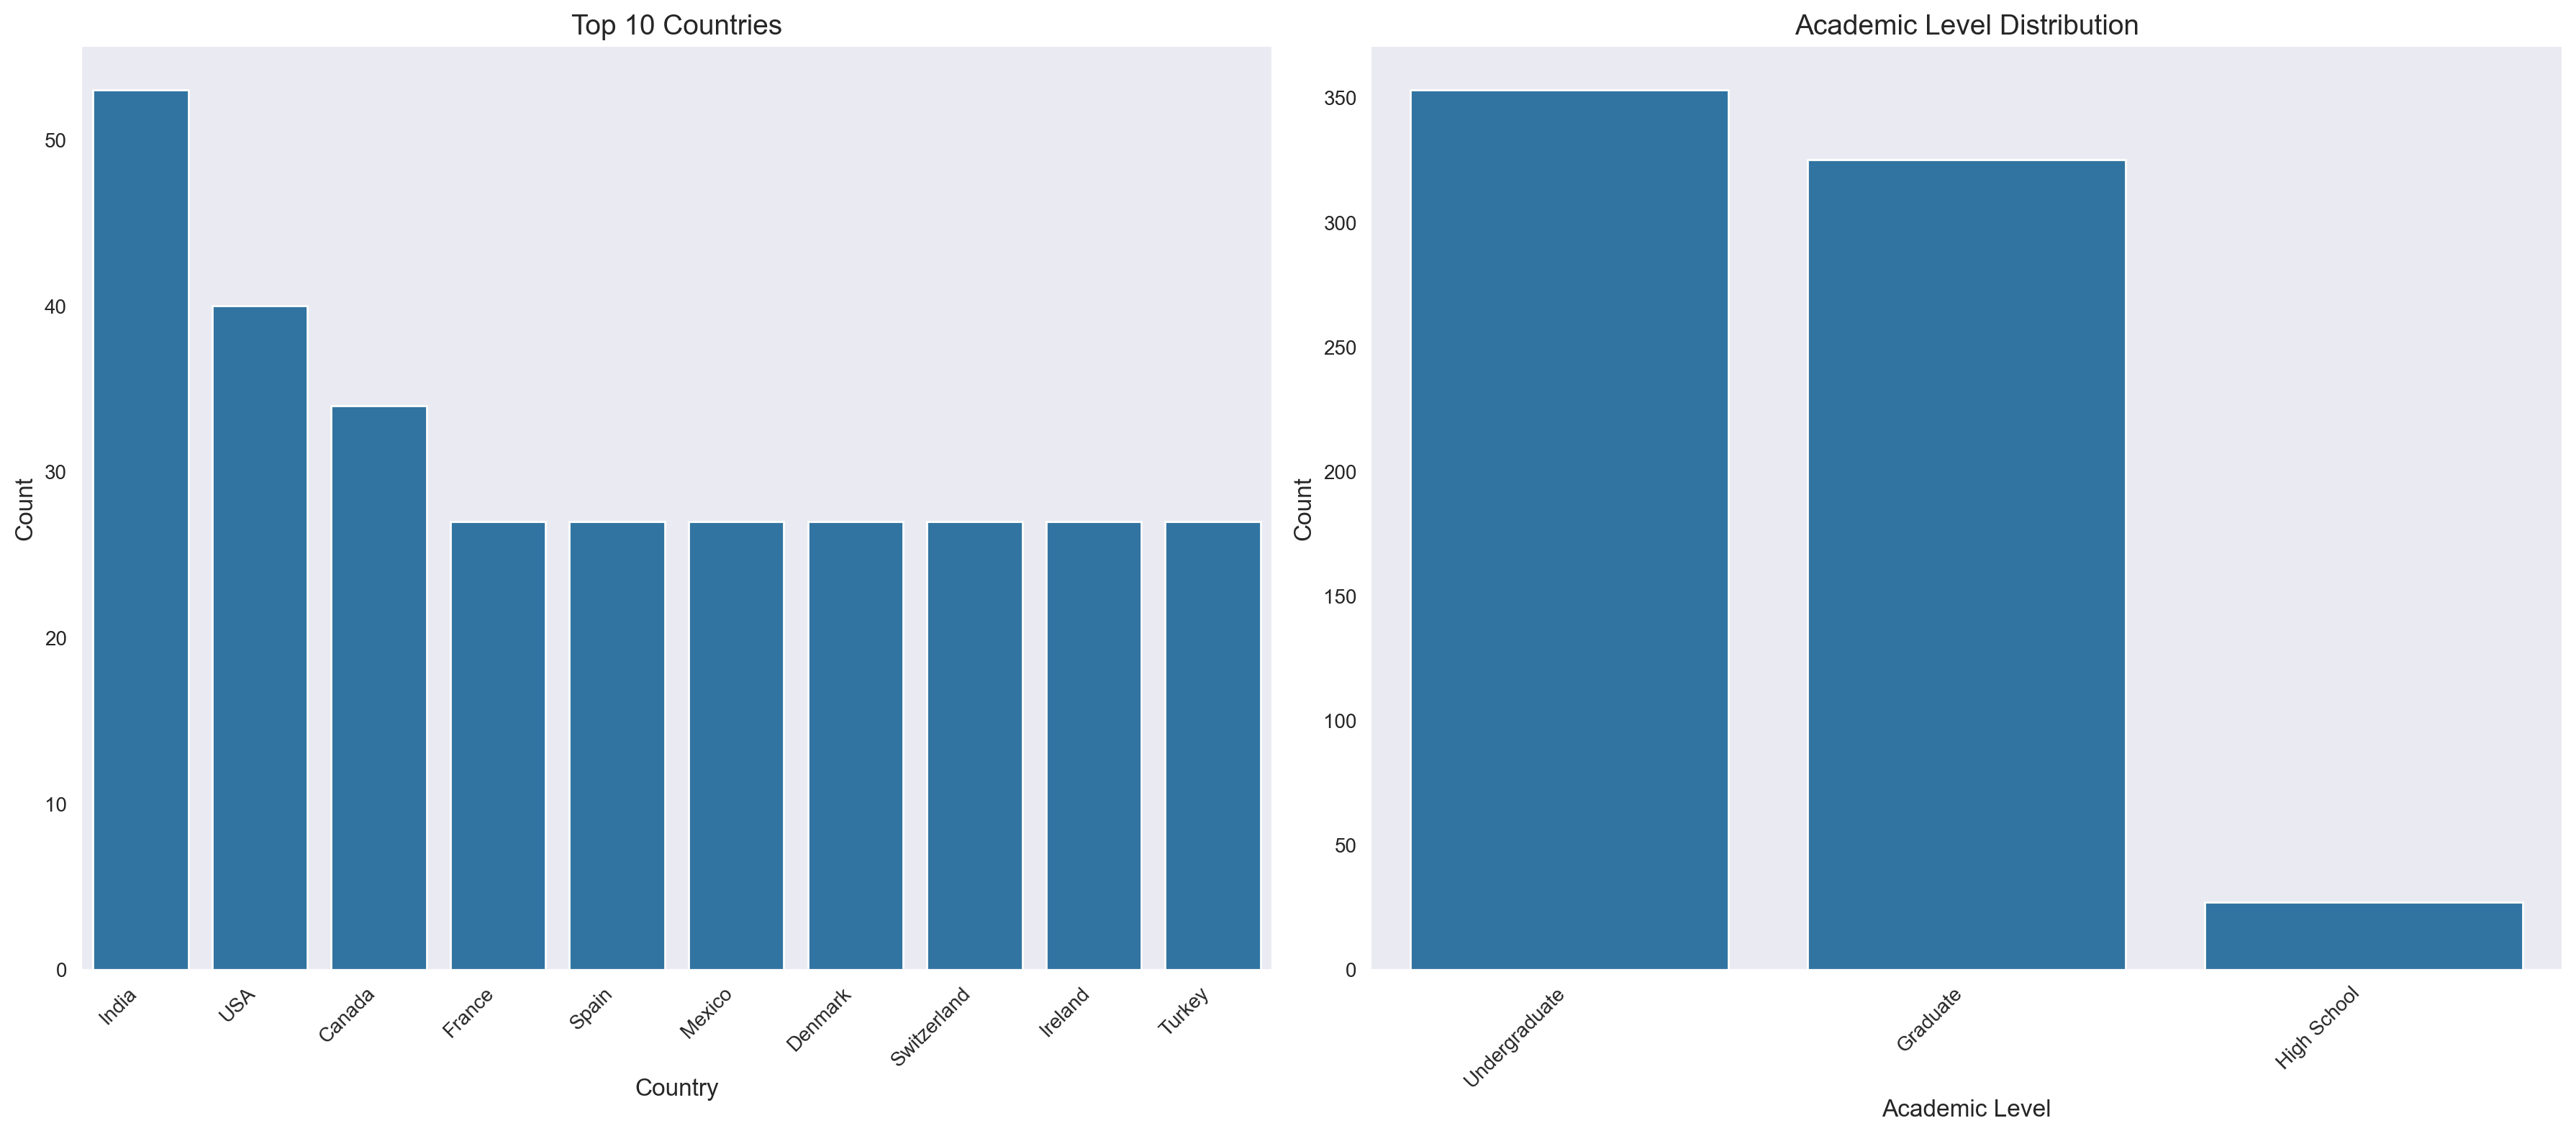

In [80]:
# #### Country and Academic Level Distribution
plt.figure(figsize=(18, 8))

# Country distribution
plt.subplot(1, 2, 1)
country_counts = df['Country'].value_counts().head(10)  # Top 10 countries
sns.barplot(x=country_counts.index, y=country_counts.values)
plt.title('Top 10 Countries', fontsize=14)
plt.xlabel('Country', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45, ha='right')

# Academic level distribution
plt.subplot(1, 2, 2)
academic_counts = df['Academic_Level'].value_counts()
sns.barplot(x=academic_counts.index, y=academic_counts.values)
plt.title('Academic Level Distribution', fontsize=14)
plt.xlabel('Academic Level', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

### 2. Social Media Usage Patterns

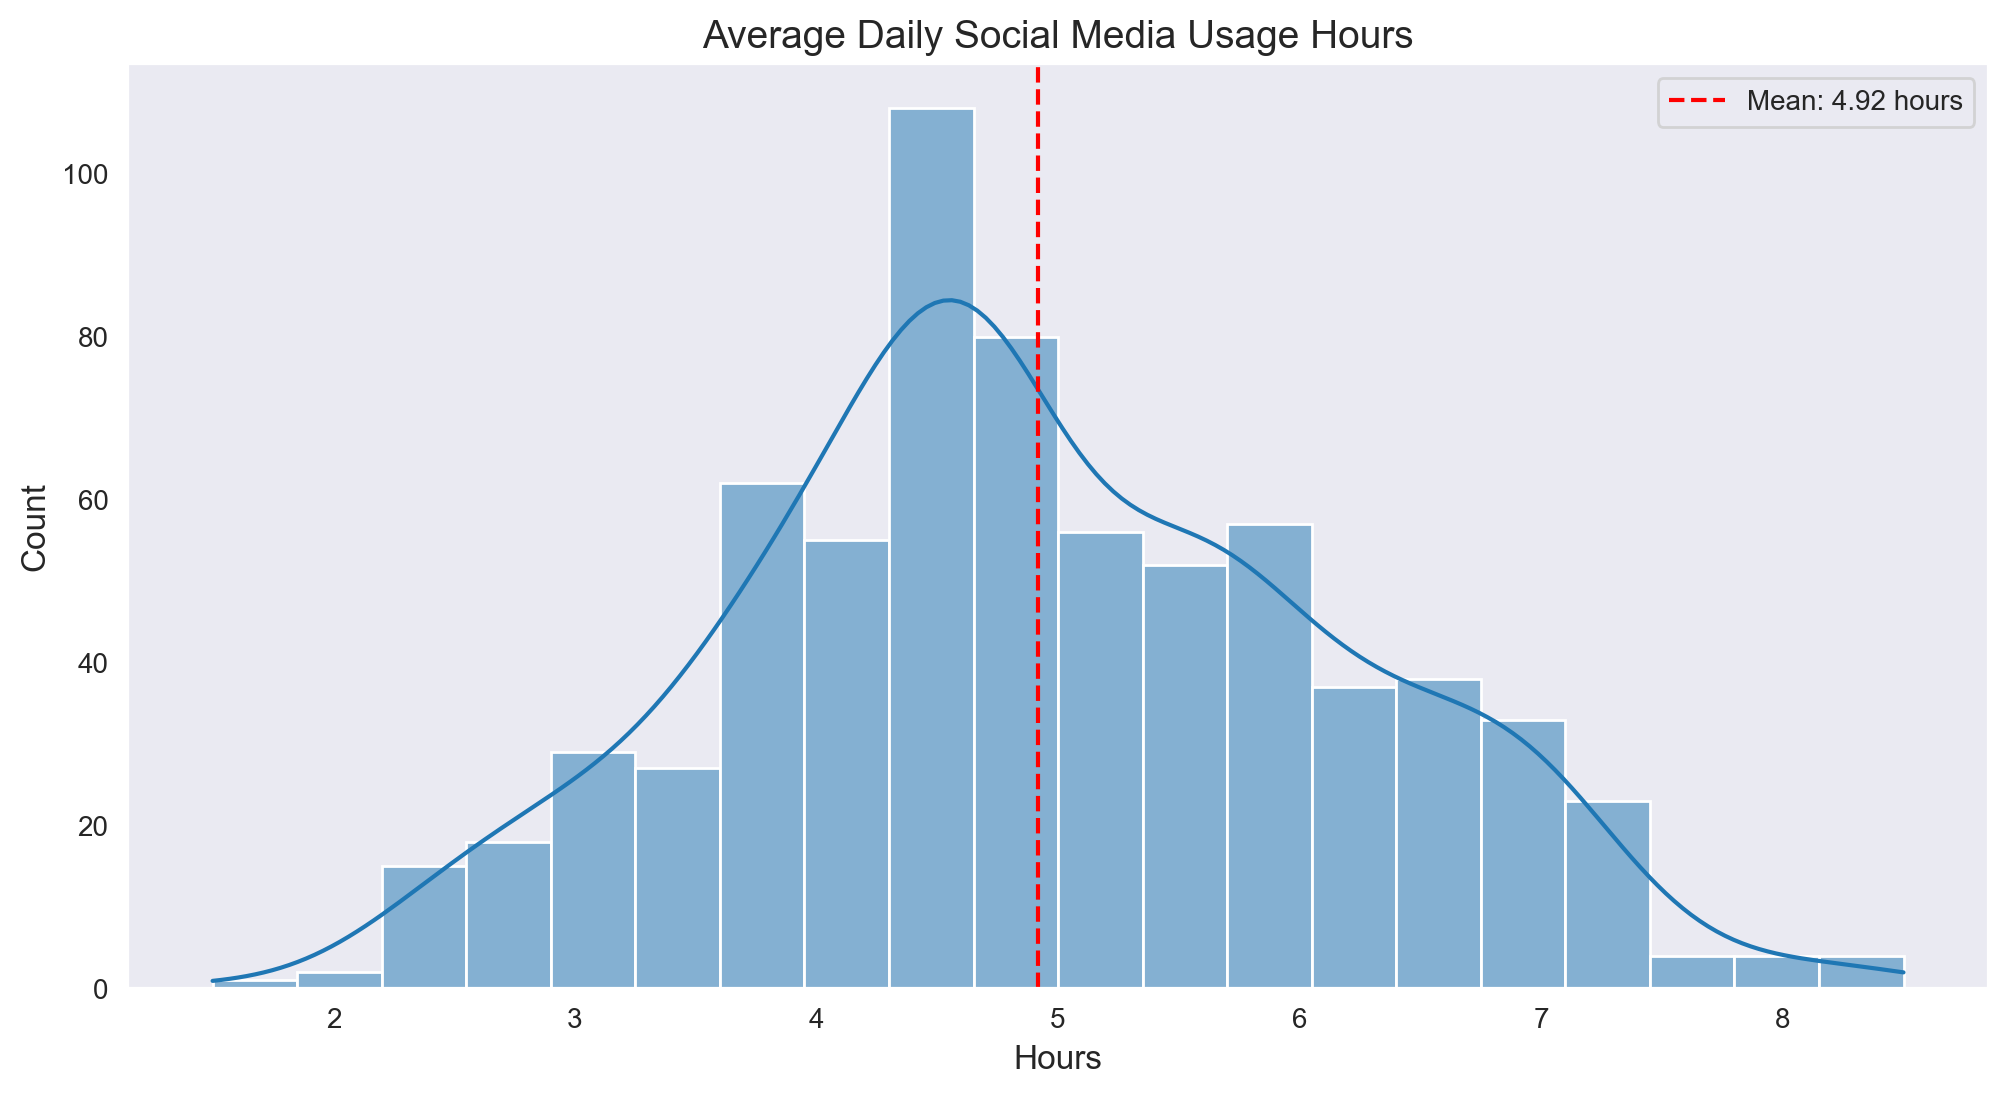

In [81]:
# #### Average Daily Usage Hours
plt.figure(figsize=(12, 6))
sns.histplot(df['Avg_Daily_Usage_Hours'], kde=True, bins=20)
plt.title('Average Daily Social Media Usage Hours', fontsize=14)
plt.xlabel('Hours', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.axvline(df['Avg_Daily_Usage_Hours'].mean(), color='red', linestyle='--', label=f'Mean: {df["Avg_Daily_Usage_Hours"].mean():.2f} hours')
plt.legend()
plt.show()

/var/folders/cp/4gcz235n4bs8sx70mslflvpr0000gn/T/ipykernel_18692/1632667684.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=platform_counts.index, y=platform_counts.values, palette='viridis')


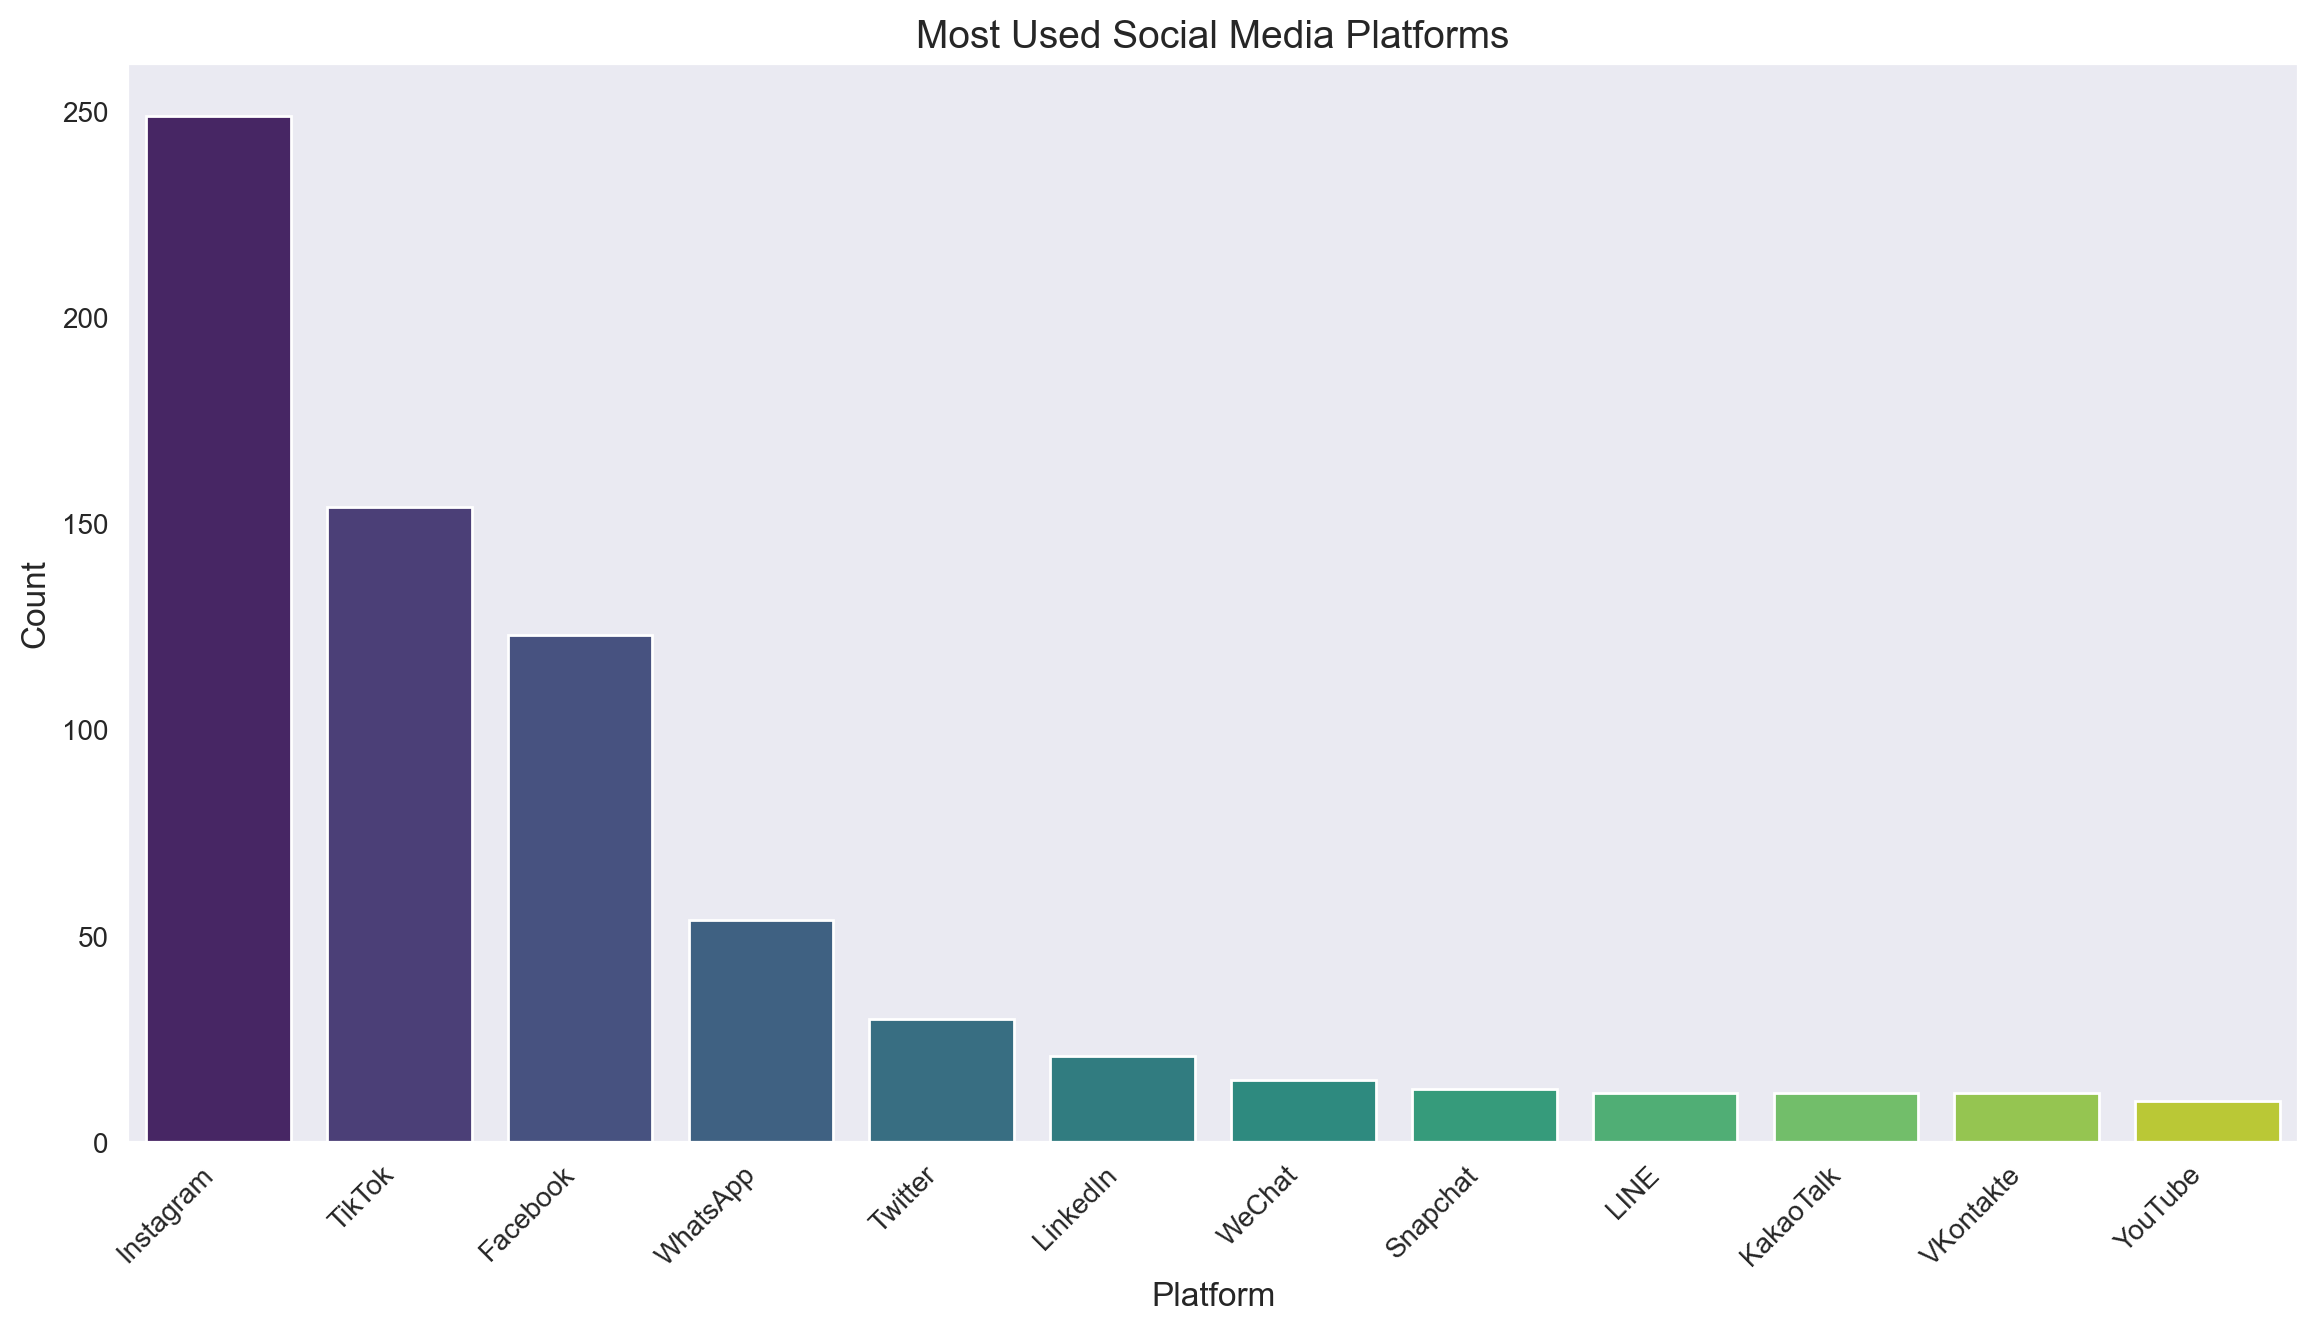

In [82]:
# #### Most Used Platforms
plt.figure(figsize=(14, 7))
platform_counts = df['Most_Used_Platform'].value_counts()
sns.barplot(x=platform_counts.index, y=platform_counts.values, palette='viridis')
plt.title('Most Used Social Media Platforms', fontsize=14)
plt.xlabel('Platform', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.show()

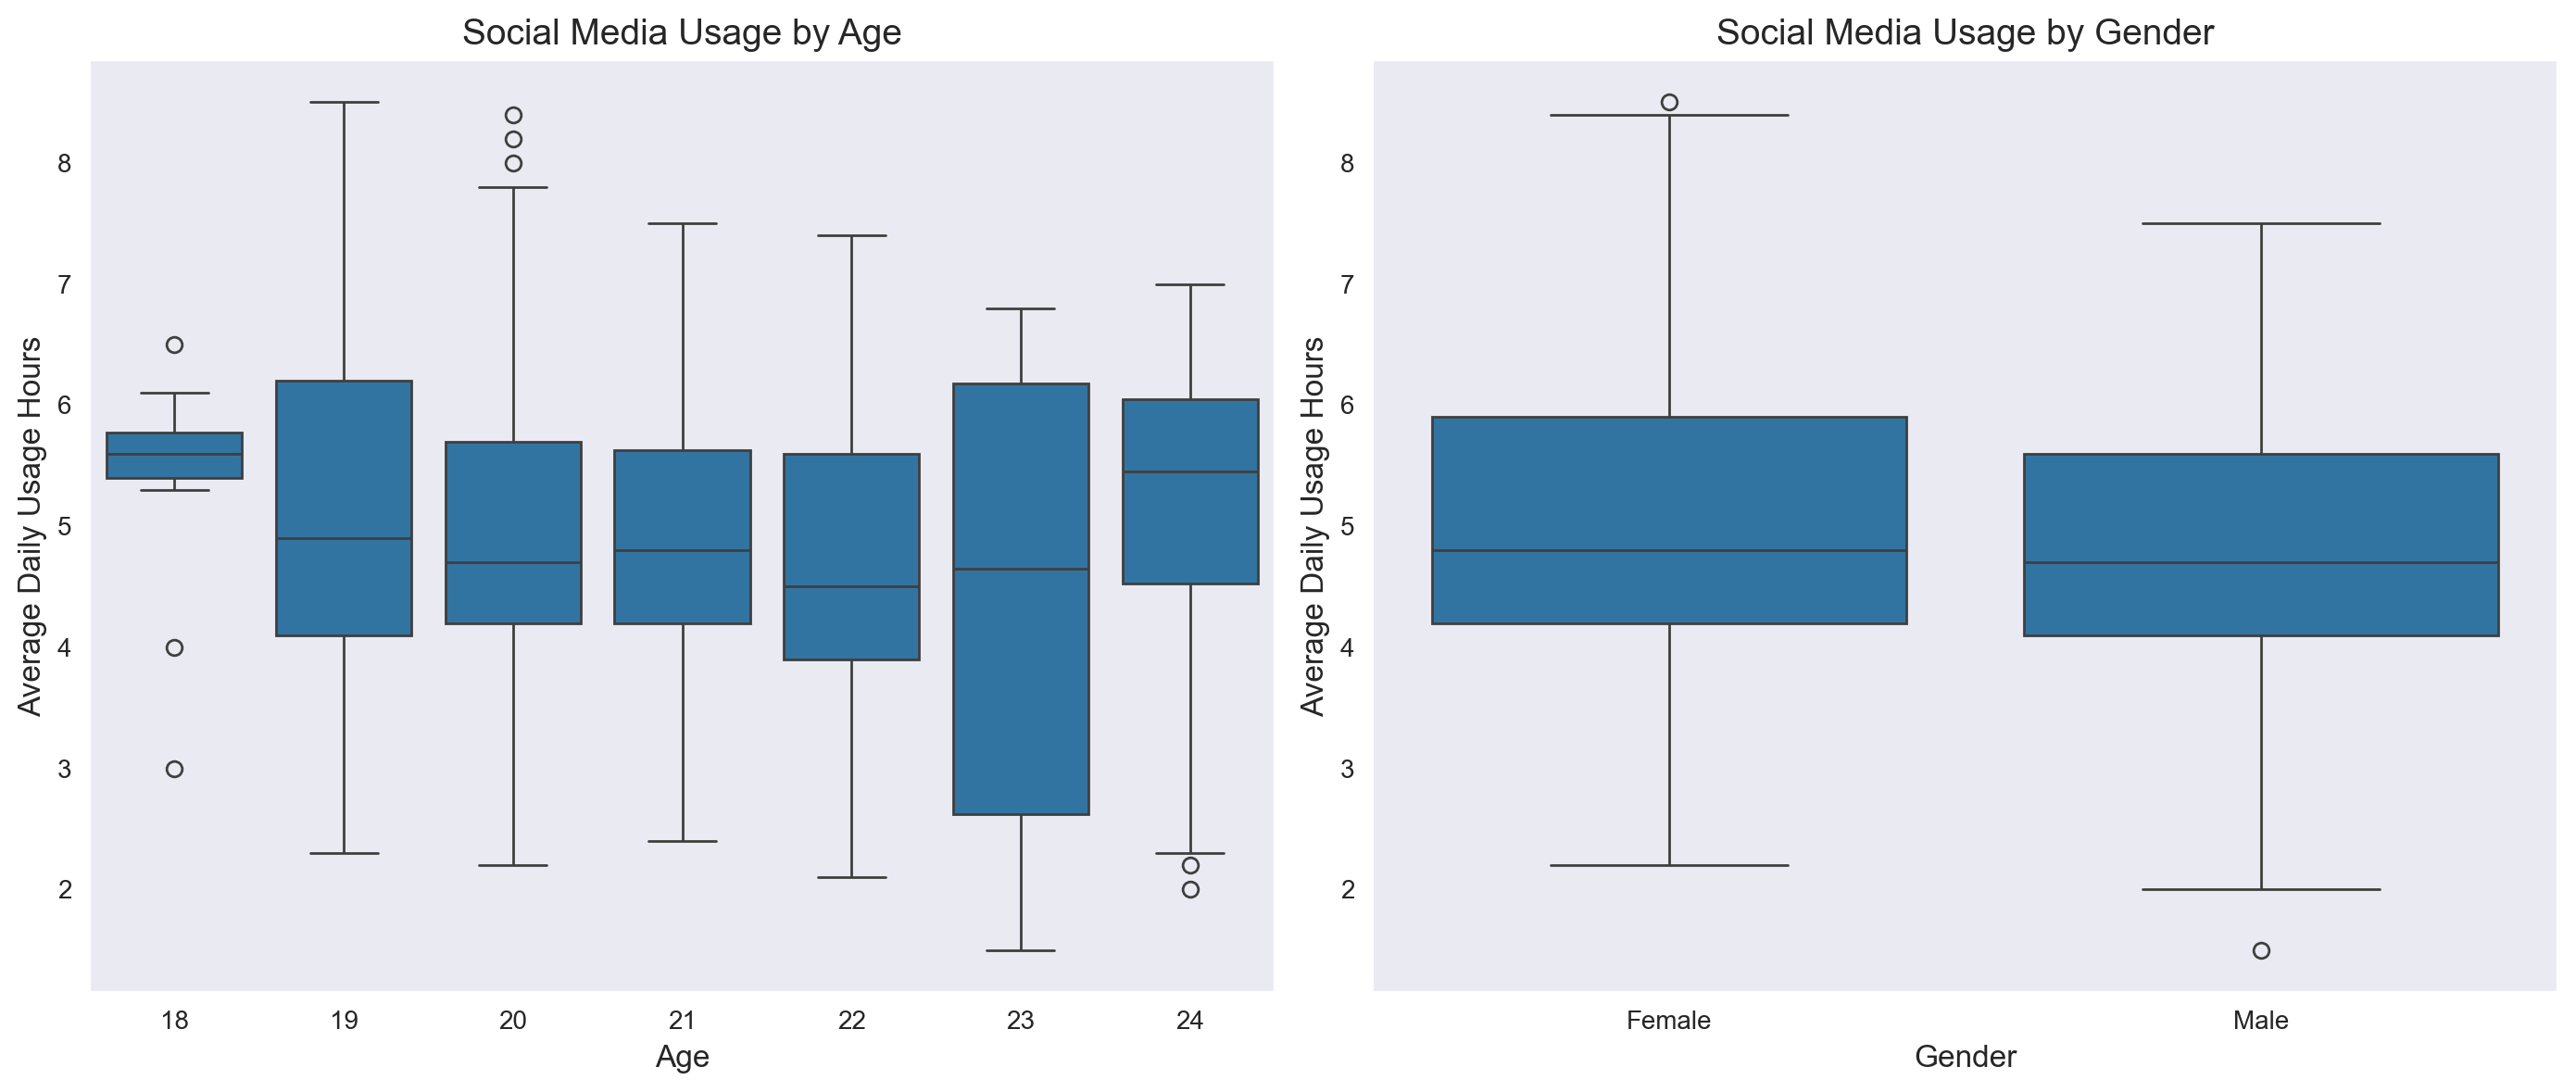

In [84]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

# Usage by age
plt.subplot(1, 2, 1)
sns.boxplot(x='Age', y='Avg_Daily_Usage_Hours', data=df)
plt.title('Social Media Usage by Age', fontsize=14)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Average Daily Usage Hours', fontsize=12)

# Usage by gender
plt.subplot(1, 2, 2)
sns.boxplot(x='Gender', y='Avg_Daily_Usage_Hours', data=df)
plt.title('Social Media Usage by Gender', fontsize=14)
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Average Daily Usage Hours', fontsize=12)

plt.tight_layout()
plt.show()

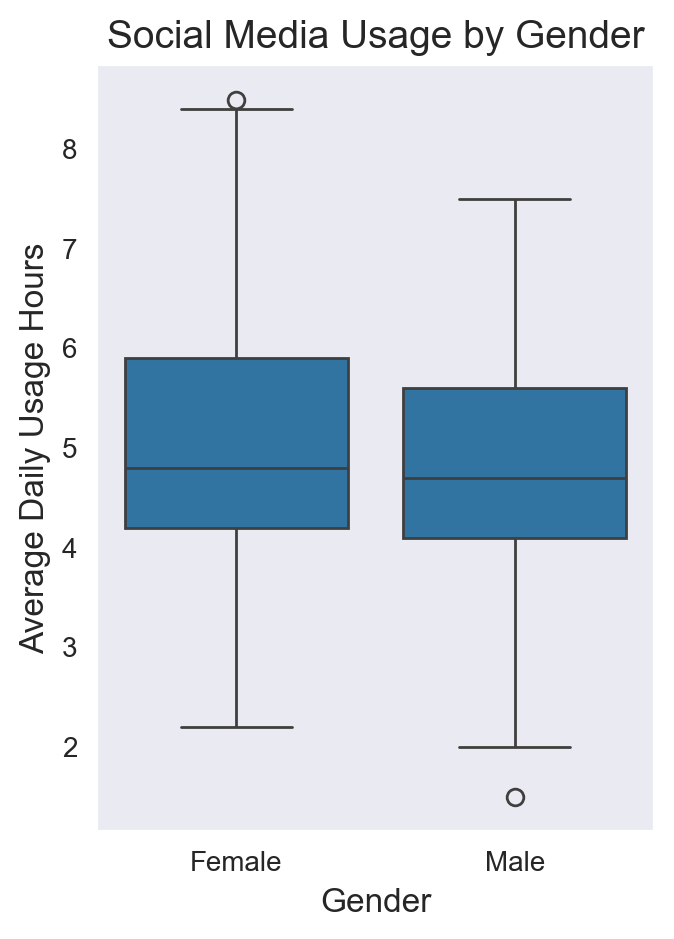

In [85]:
# Usage by gender
plt.subplot(1, 2, 2)
sns.boxplot(x='Gender', y='Avg_Daily_Usage_Hours', data=df)
plt.title('Social Media Usage by Gender', fontsize=14)
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Average Daily Usage Hours', fontsize=12)

plt.tight_layout()
plt.show()

#### 3. Academic Impact Analysis 

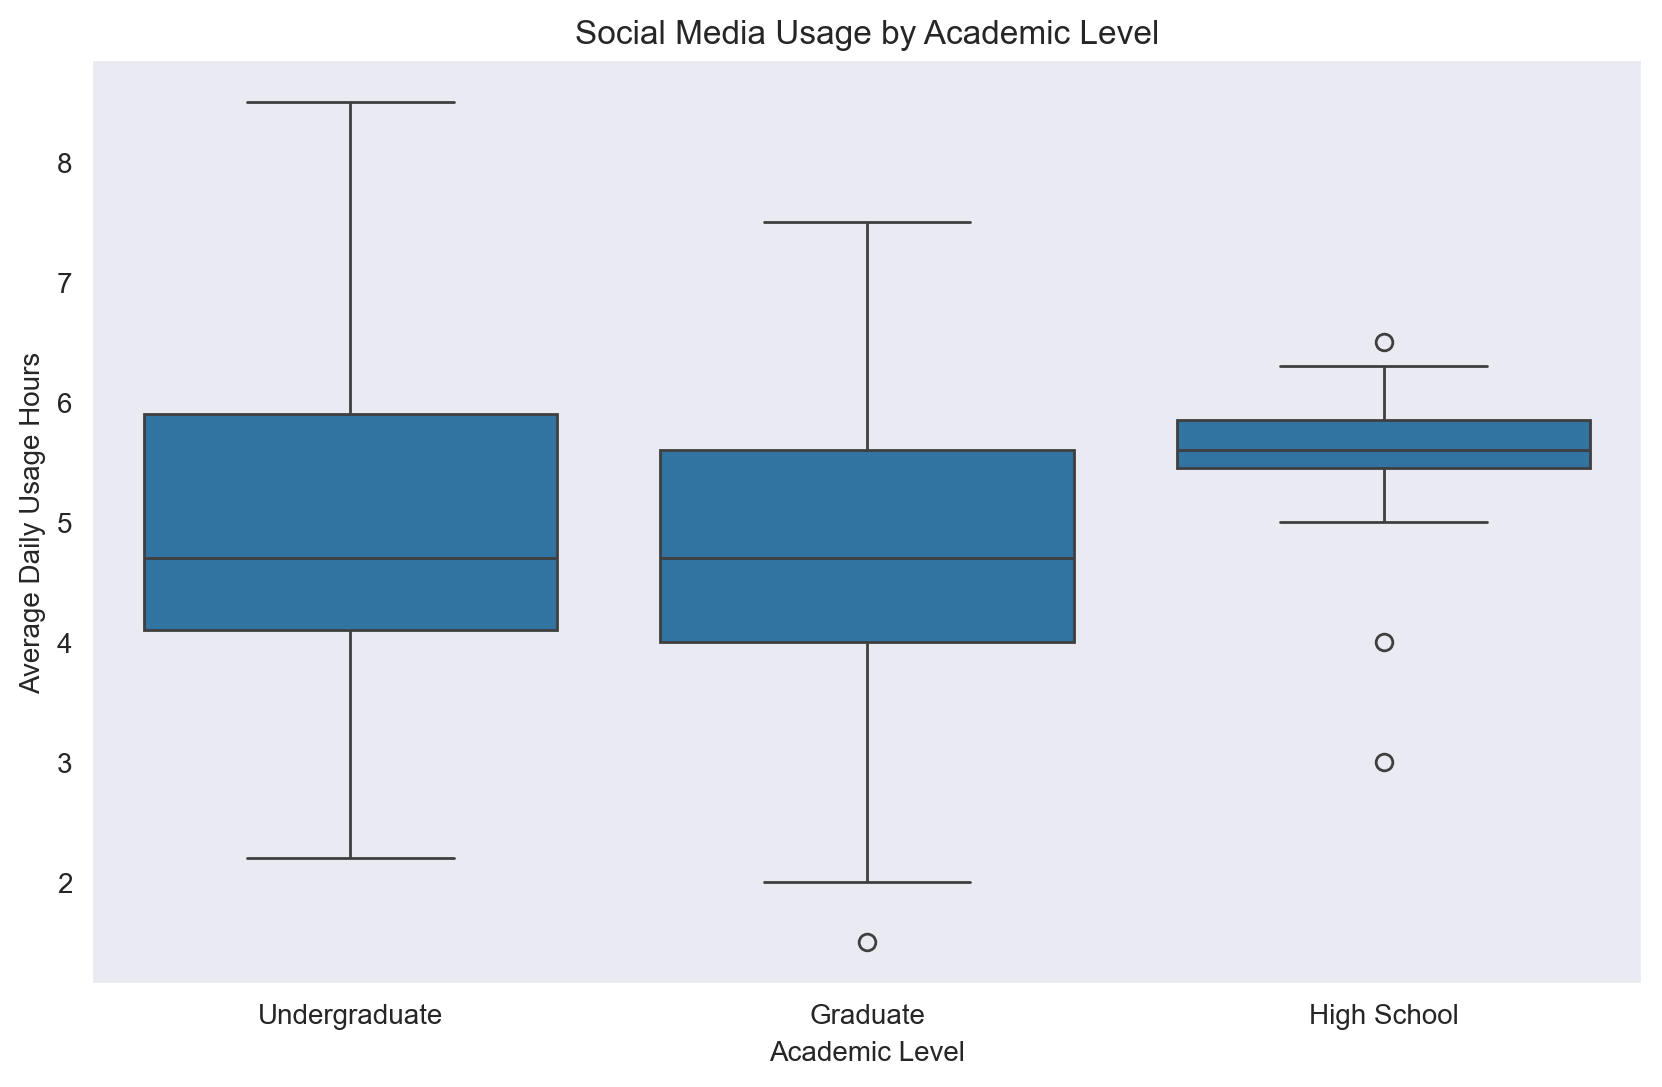

In [93]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

sns.boxplot(
    x='Academic_Level',
    y='Avg_Daily_Usage_Hours',
    data=df
)

plt.title('Social Media Usage by Academic Level')
plt.xlabel('Academic Level')
plt.ylabel('Average Daily Usage Hours')

plt.show()

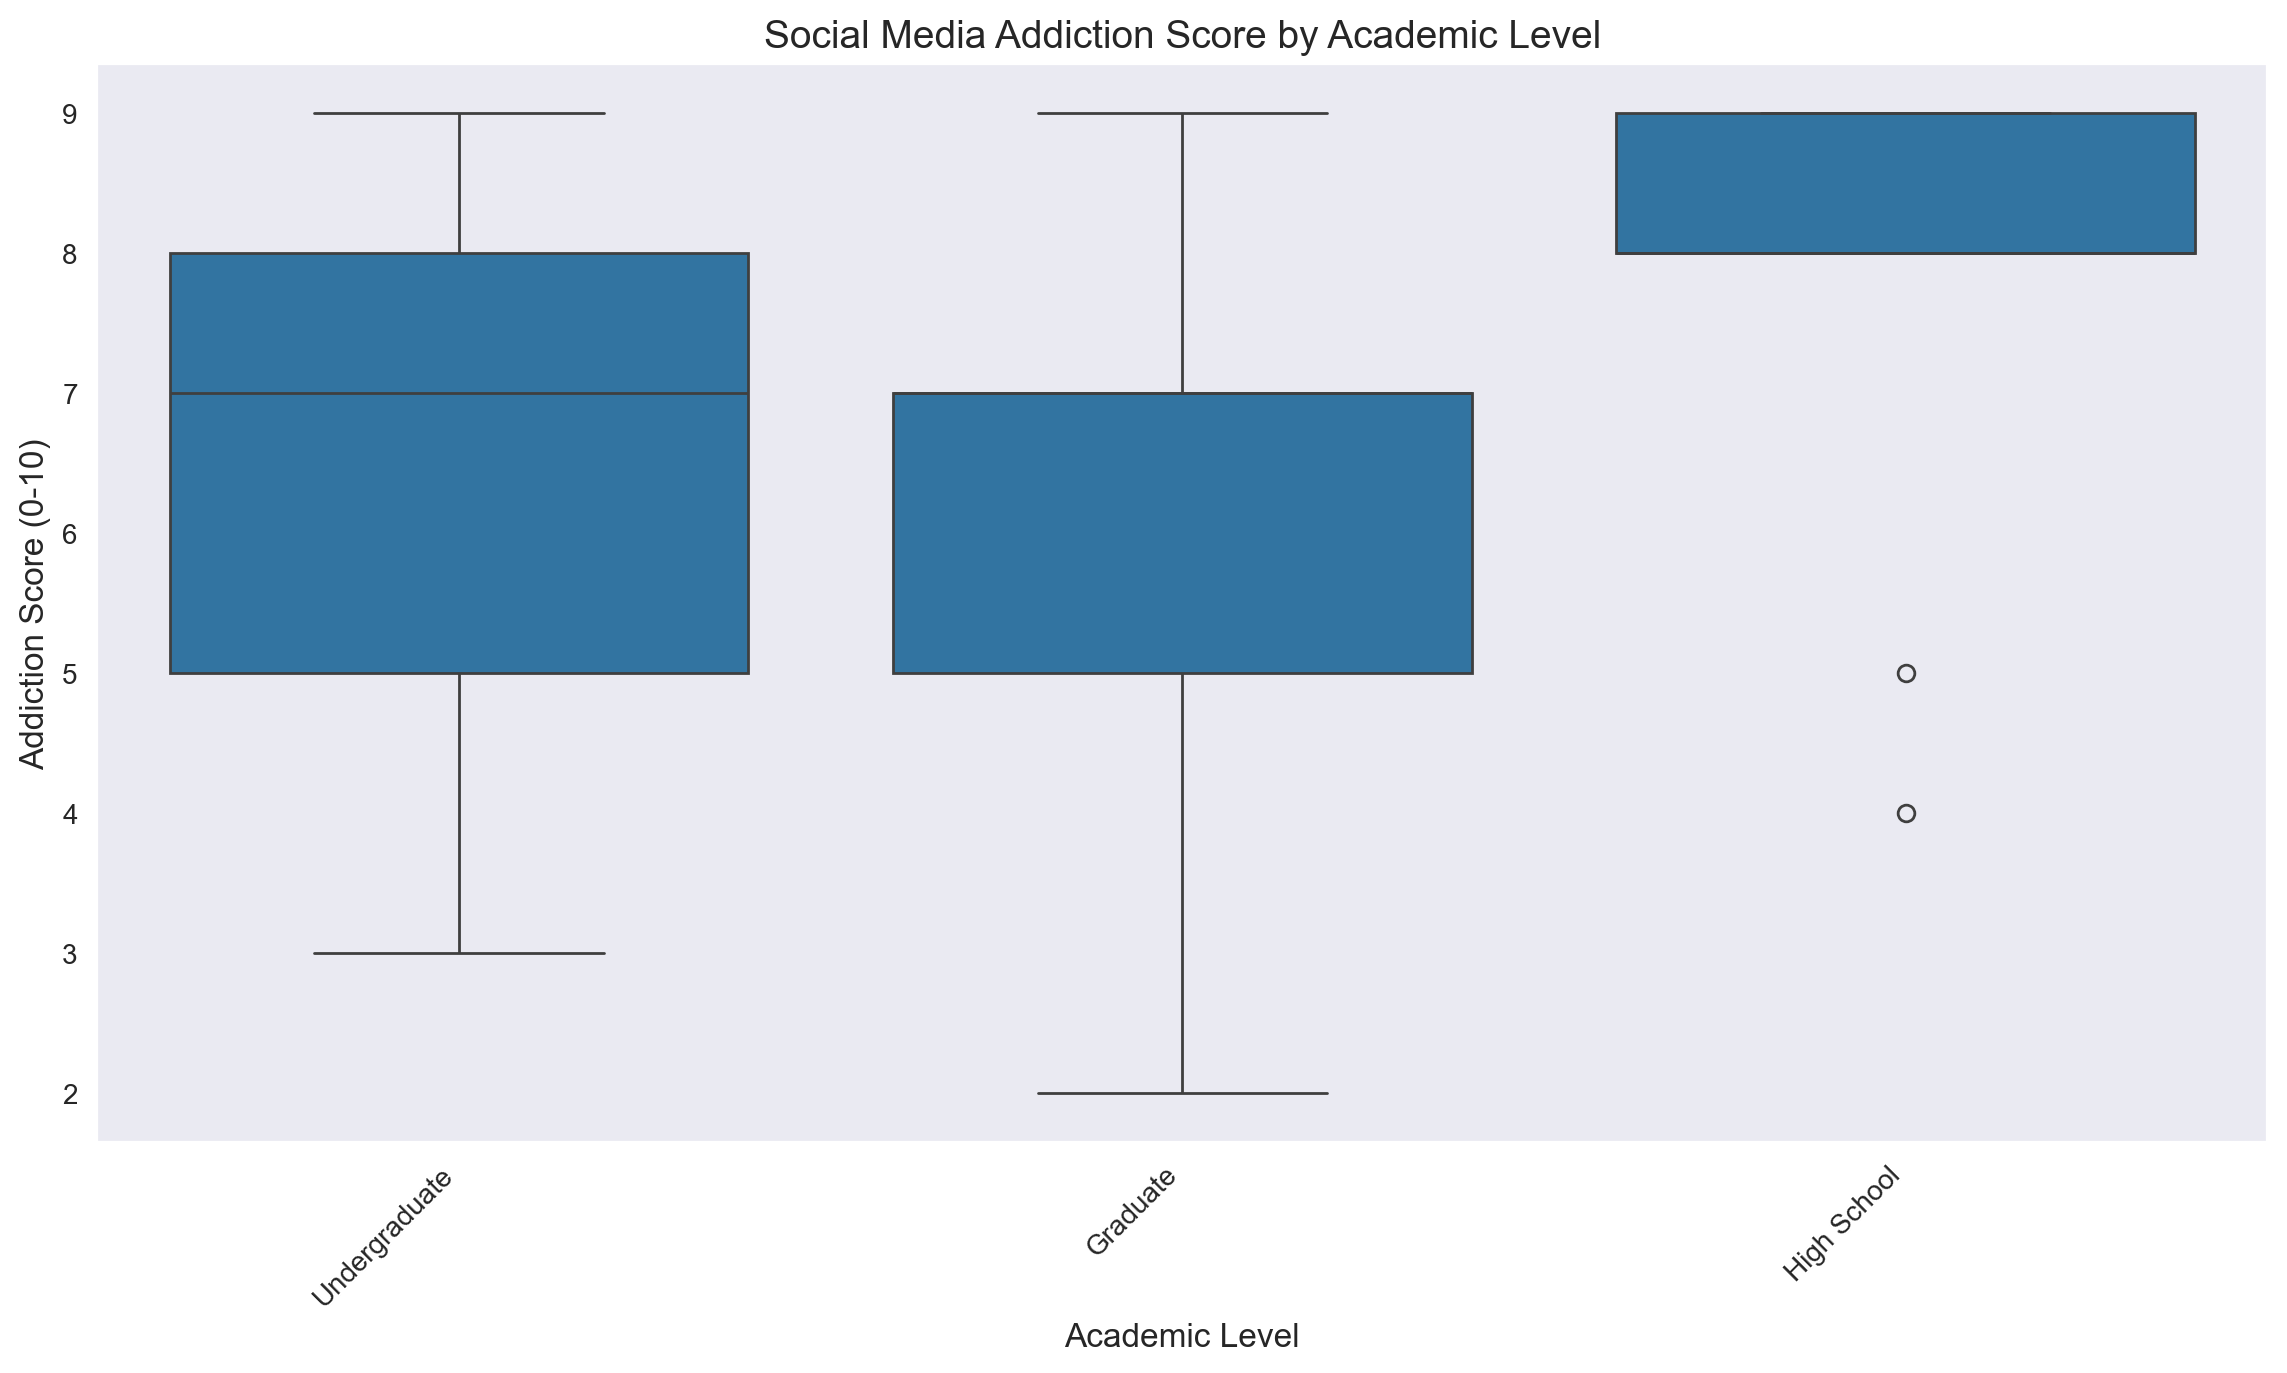

In [90]:
# #### Academic Level vs Addiction Score
plt.figure(figsize=(14, 7))
sns.boxplot(x='Academic_Level', y='Addicted_Score', data=df)
plt.title('Social Media Addiction Score by Academic Level', fontsize=14)
plt.xlabel('Academic Level', fontsize=12)
plt.ylabel('Addiction Score (0-10)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.show()

In [95]:
import pandas as pd

df['Usage_Category'] = pd.cut(
    df['Avg_Daily_Usage_Hours'],
    bins=[0, 2, 4, 6, 24],
    labels=['Low', 'Moderate', 'High', 'Very High'],
    include_lowest=True
)

In [96]:
academic_impact_by_usage = pd.crosstab(
    df['Usage_Category'],
    df['Affects_Academic_Performance']
)

academic_impact_by_usage_percentage = academic_impact_by_usage.div(
    academic_impact_by_usage.sum(axis=1),
    axis=0
) * 100

academic_impact_by_usage_percentage

Affects_Academic_Performance,No,Yes
Usage_Category,,
Low,100.000000,0.000000
Moderate,84.431138,15.568862
High,27.735369,72.264631
Very High,0.000000,100.000000


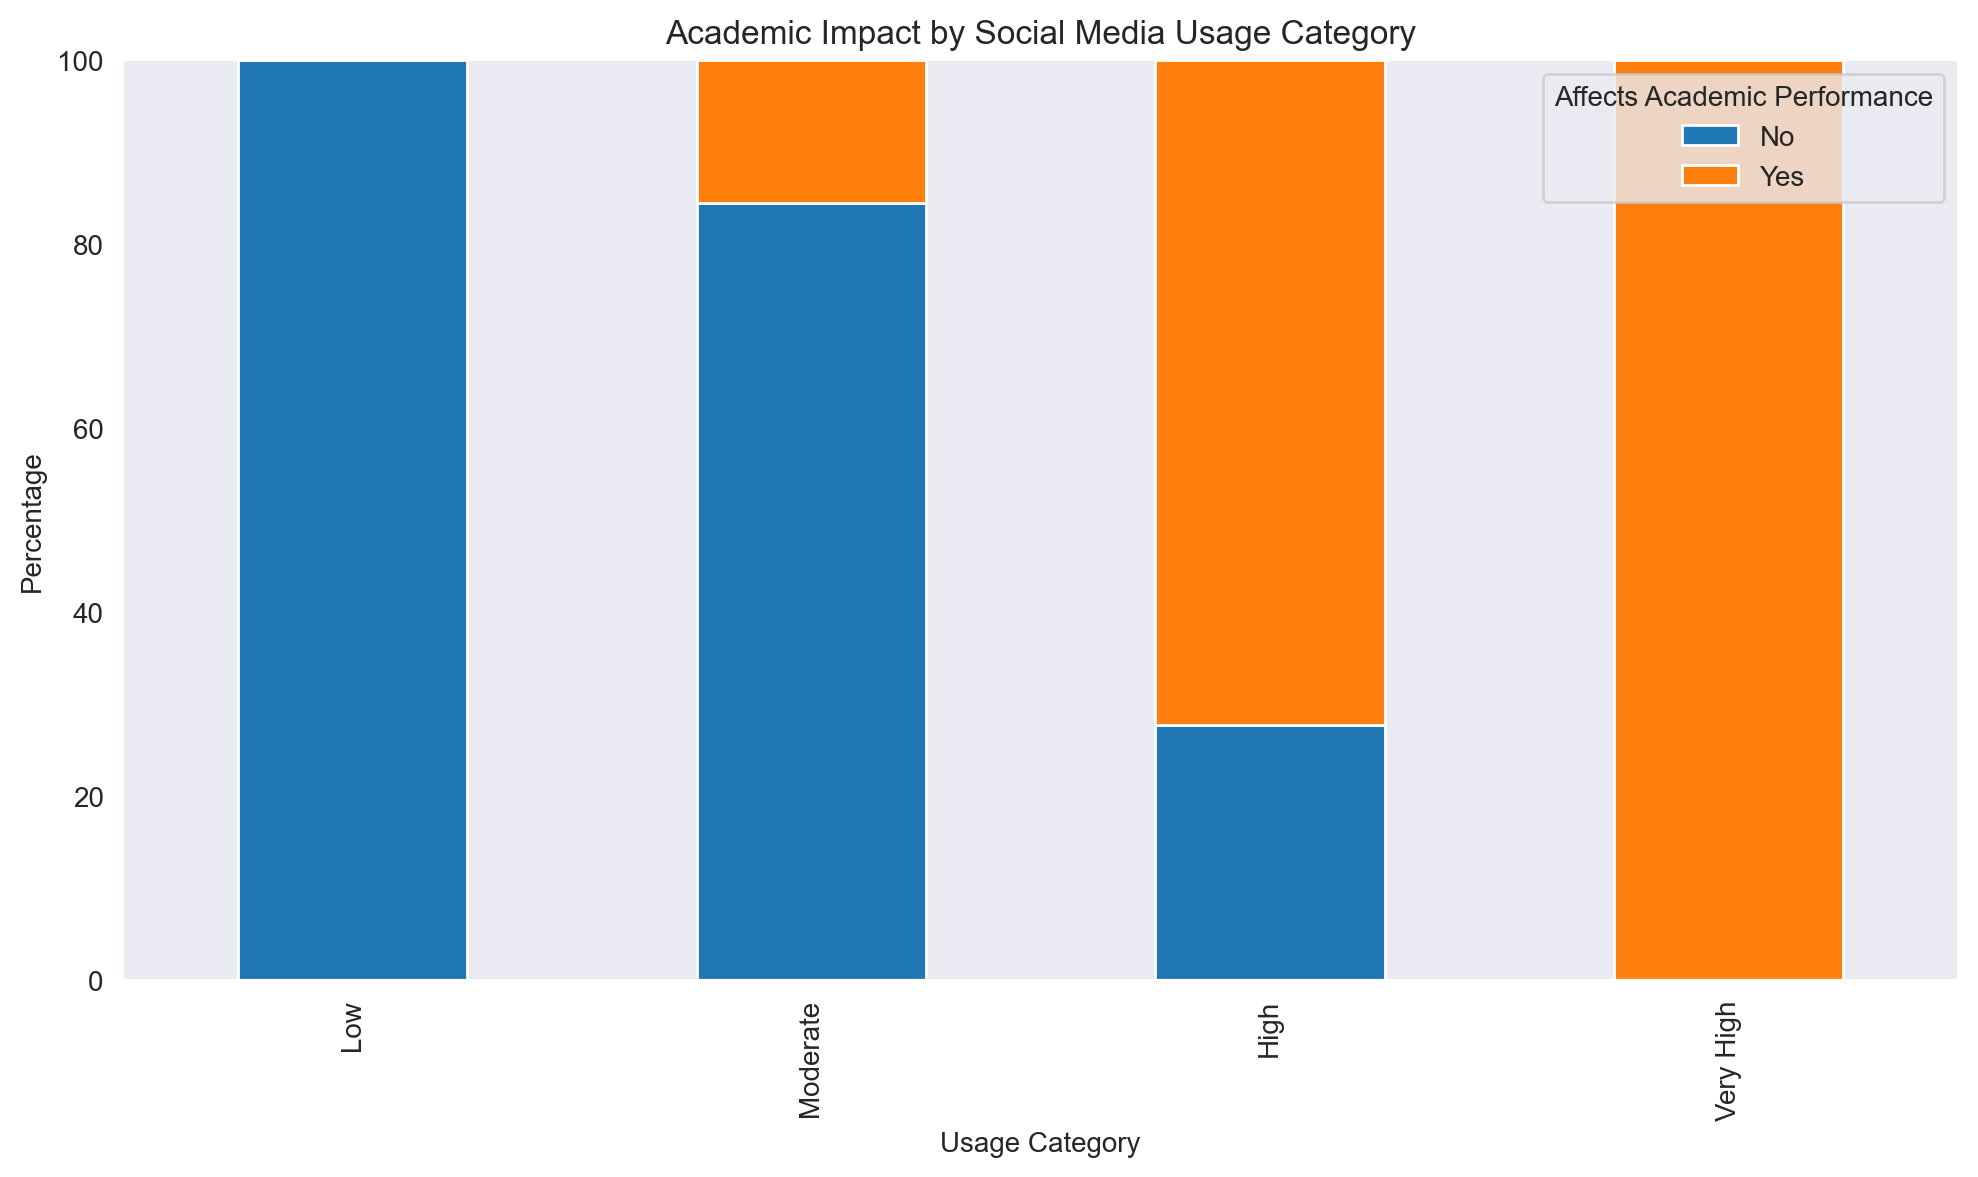

In [97]:
academic_impact_by_usage_percentage.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6)
)

plt.title('Academic Impact by Social Media Usage Category')
plt.xlabel('Usage Category')
plt.ylabel('Percentage')
plt.legend(title='Affects Academic Performance')
plt.tight_layout()
plt.show()

#### 4. Mental Health and Sleep Analysis

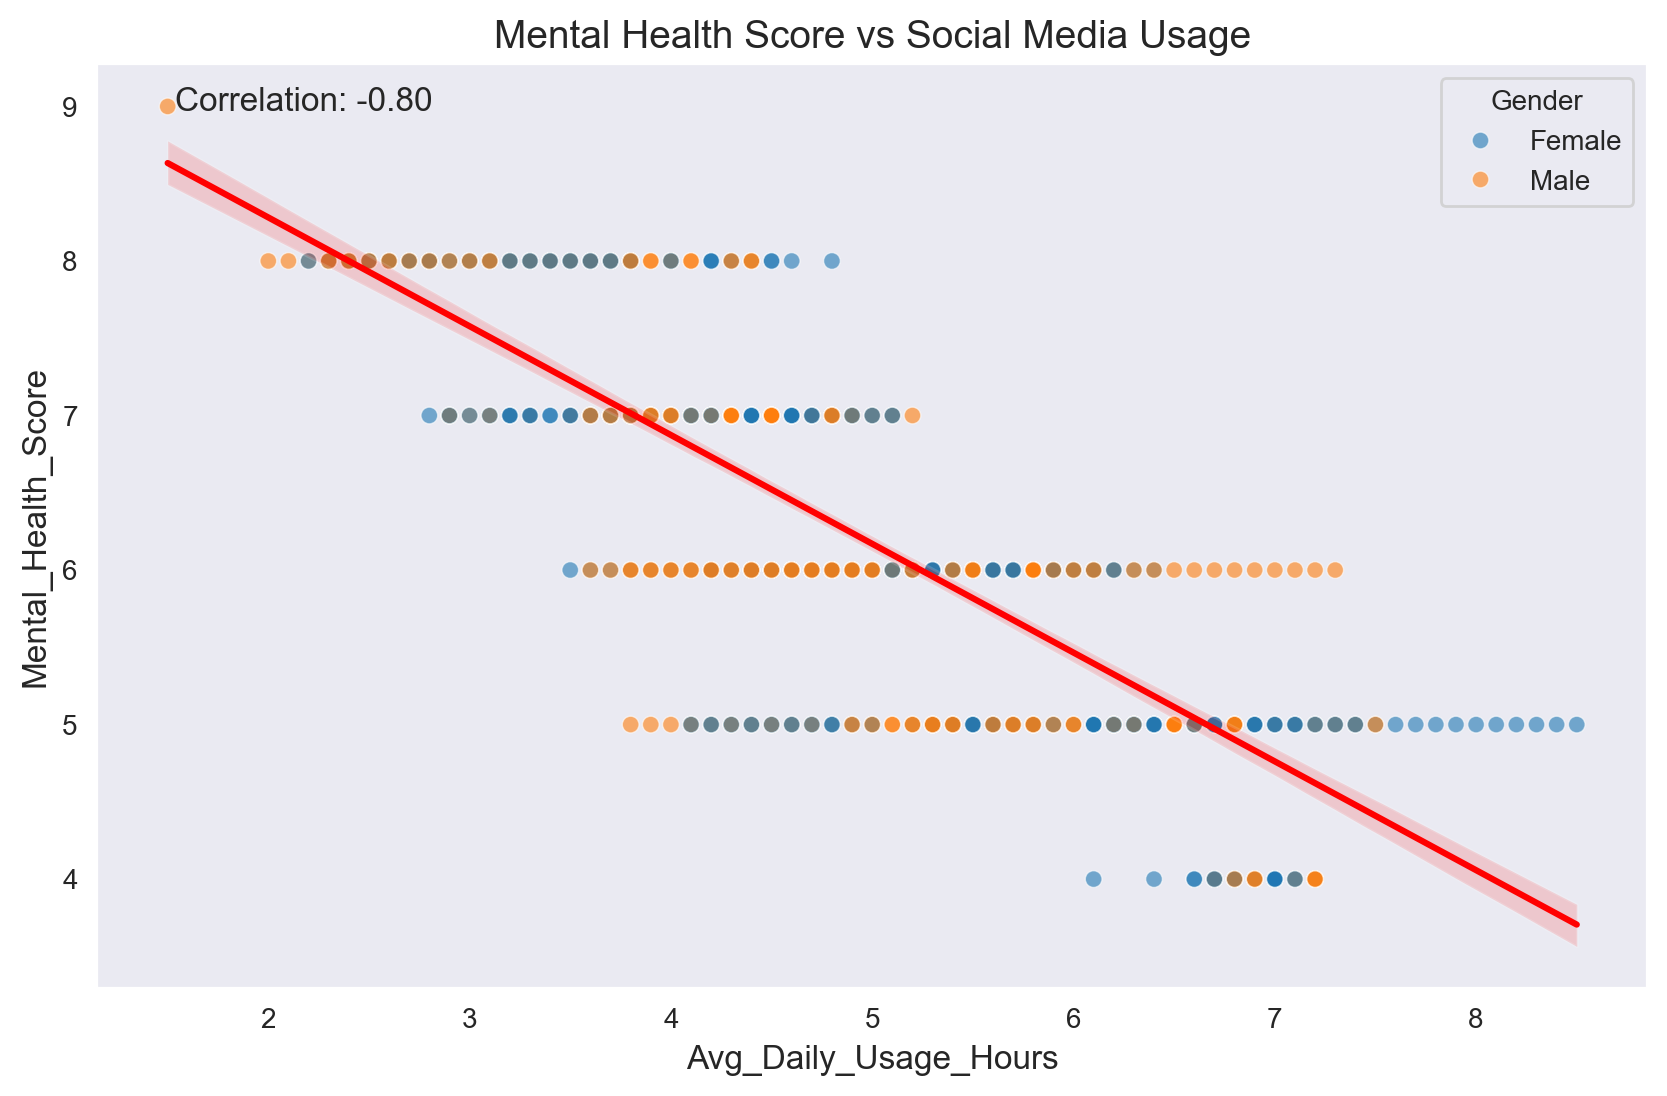

In [98]:
# #### Mental Health Score vs Social Media Usage
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Avg_Daily_Usage_Hours', y='Mental_Health_Score', data=df, alpha=0.6, hue='Gender')
plt.title('Mental Health Score vs Social Media Usage', fontsize=14)
plt.xlabel('Average Daily Usage Hours', fontsize=12)
plt.ylabel('Mental Health Score (0-10)', fontsize=12)

# Add regression line
sns.regplot(x='Avg_Daily_Usage_Hours', y='Mental_Health_Score', data=df, scatter=False, color='red')

# Calculate correlation
correlation = df['Avg_Daily_Usage_Hours'].corr(df['Mental_Health_Score'])
plt.annotate(f'Correlation: {correlation:.2f}', xy=(0.05, 0.95), xycoords='axes fraction', fontsize=12)

plt.show()

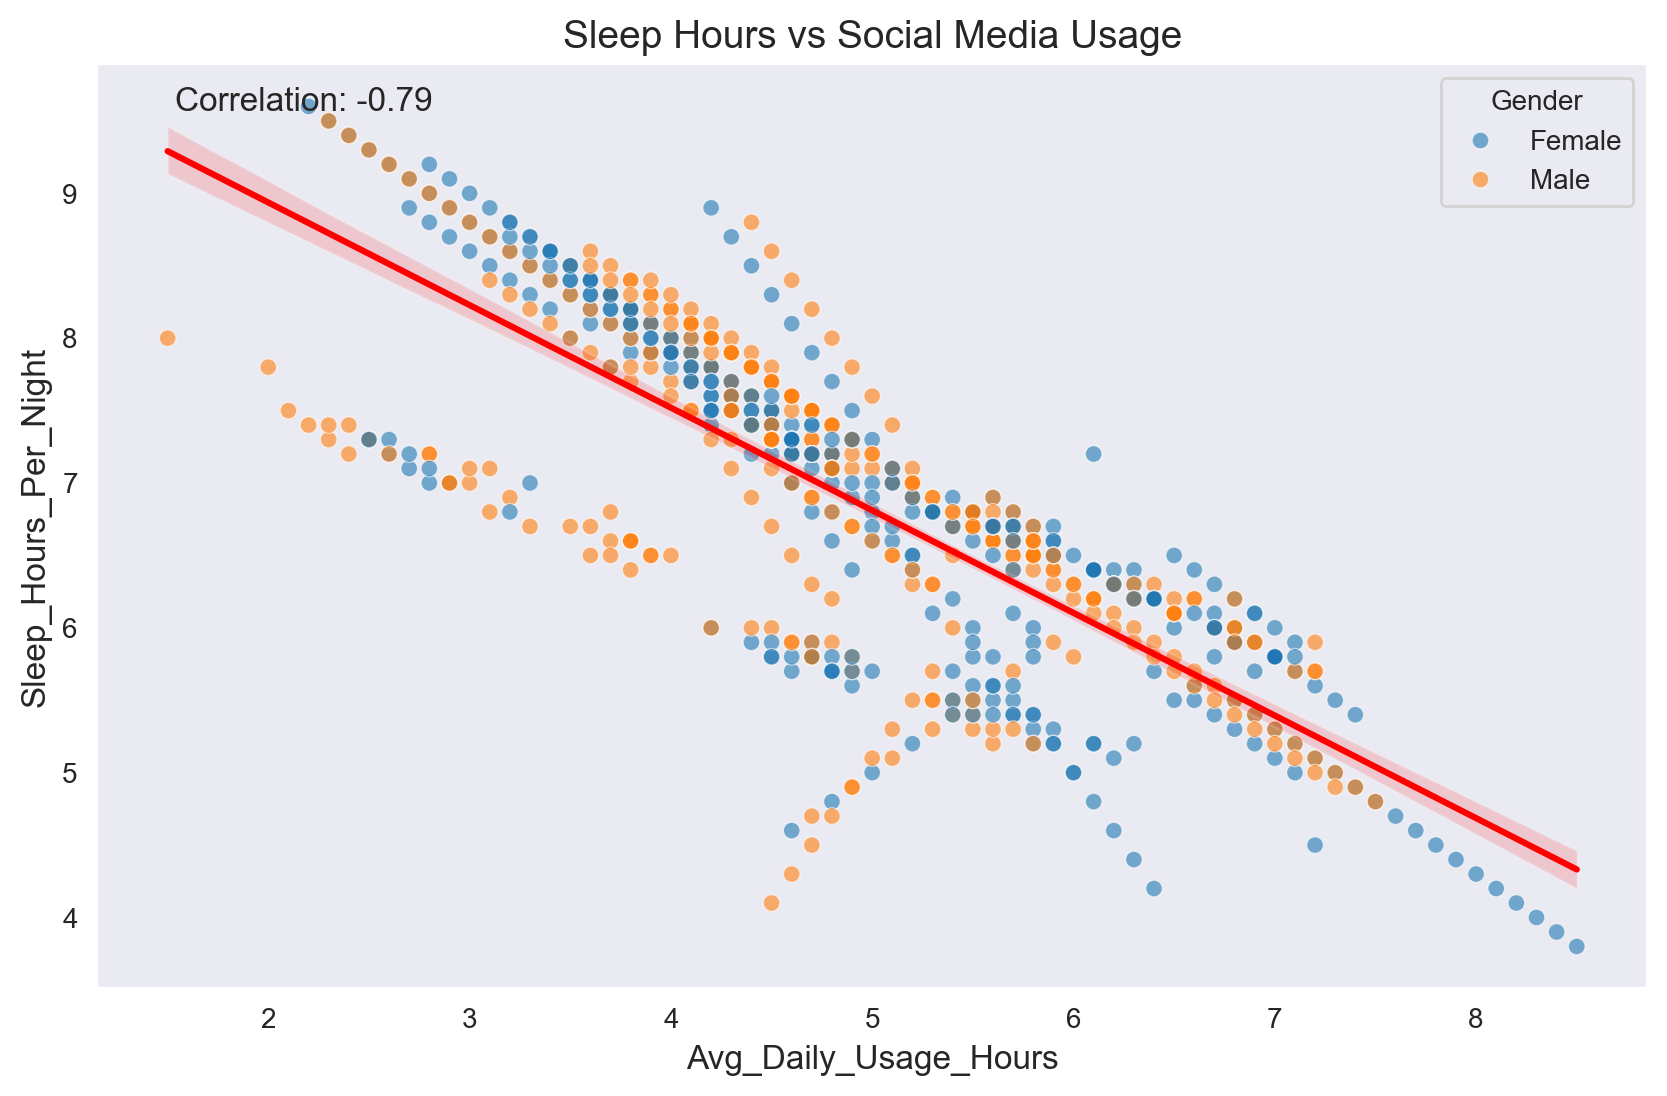

In [99]:
# #### Sleep Hours vs Social Media Usage
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Avg_Daily_Usage_Hours', y='Sleep_Hours_Per_Night', data=df, alpha=0.6, hue='Gender')
plt.title('Sleep Hours vs Social Media Usage', fontsize=14)
plt.xlabel('Average Daily Usage Hours', fontsize=12)
plt.ylabel('Sleep Hours Per Night', fontsize=12)

# Add regression line
sns.regplot(x='Avg_Daily_Usage_Hours', y='Sleep_Hours_Per_Night', data=df, scatter=False, color='red')

# Calculate correlation
correlation = df['Avg_Daily_Usage_Hours'].corr(df['Sleep_Hours_Per_Night'])
plt.annotate(f'Correlation: {correlation:.2f}', xy=(0.05, 0.95), xycoords='axes fraction', fontsize=12)

plt.show()

In [101]:
df.columns.tolist()

['Student_ID',
 'Age',
 'Gender',
 'Academic_Level',
 'Country',
 'Avg_Daily_Usage_Hours',
 'Most_Used_Platform',
 'Affects_Academic_Performance',
 'Sleep_Hours_Per_Night',
 'Mental_Health_Score',
 'Relationship_Status',
 'Conflicts_Over_Social_Media',
 'Addicted_Score',
 'Usage_Category']

In [102]:
df['Sleep_Category'] = pd.cut(
    df['Sleep_Hours_Per_Night'],
    bins=[0, 5, 7, 9, 24],
    labels=['Poor', 'Average', 'Good', 'Very Good'],
    include_lowest=True
)

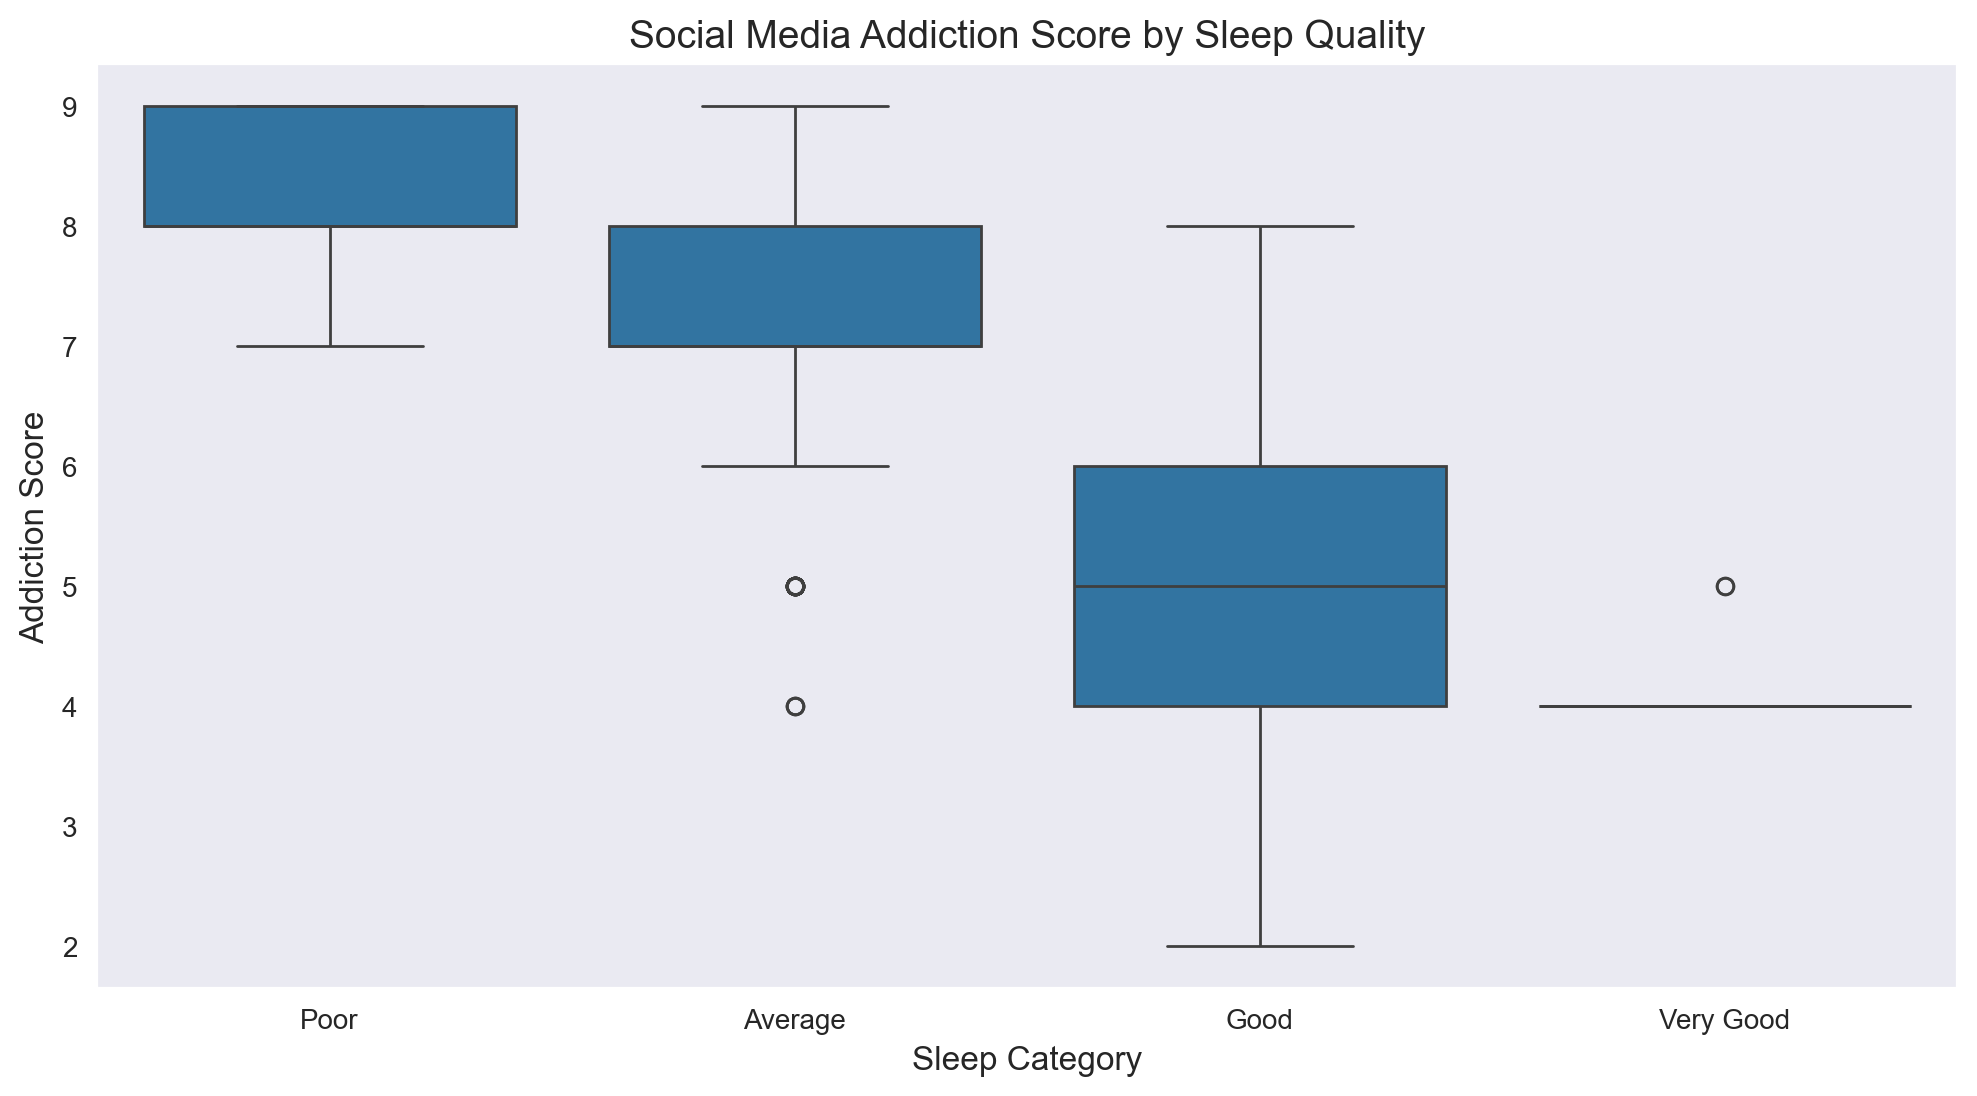

In [103]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='Sleep_Category', y='Addicted_Score', data=df)
plt.title('Social Media Addiction Score by Sleep Quality', fontsize=14)
plt.xlabel('Sleep Category', fontsize=12)
plt.ylabel('Addiction Score', fontsize=12)
plt.show()

#### 5. Relationship Status and Conflicts Analysis

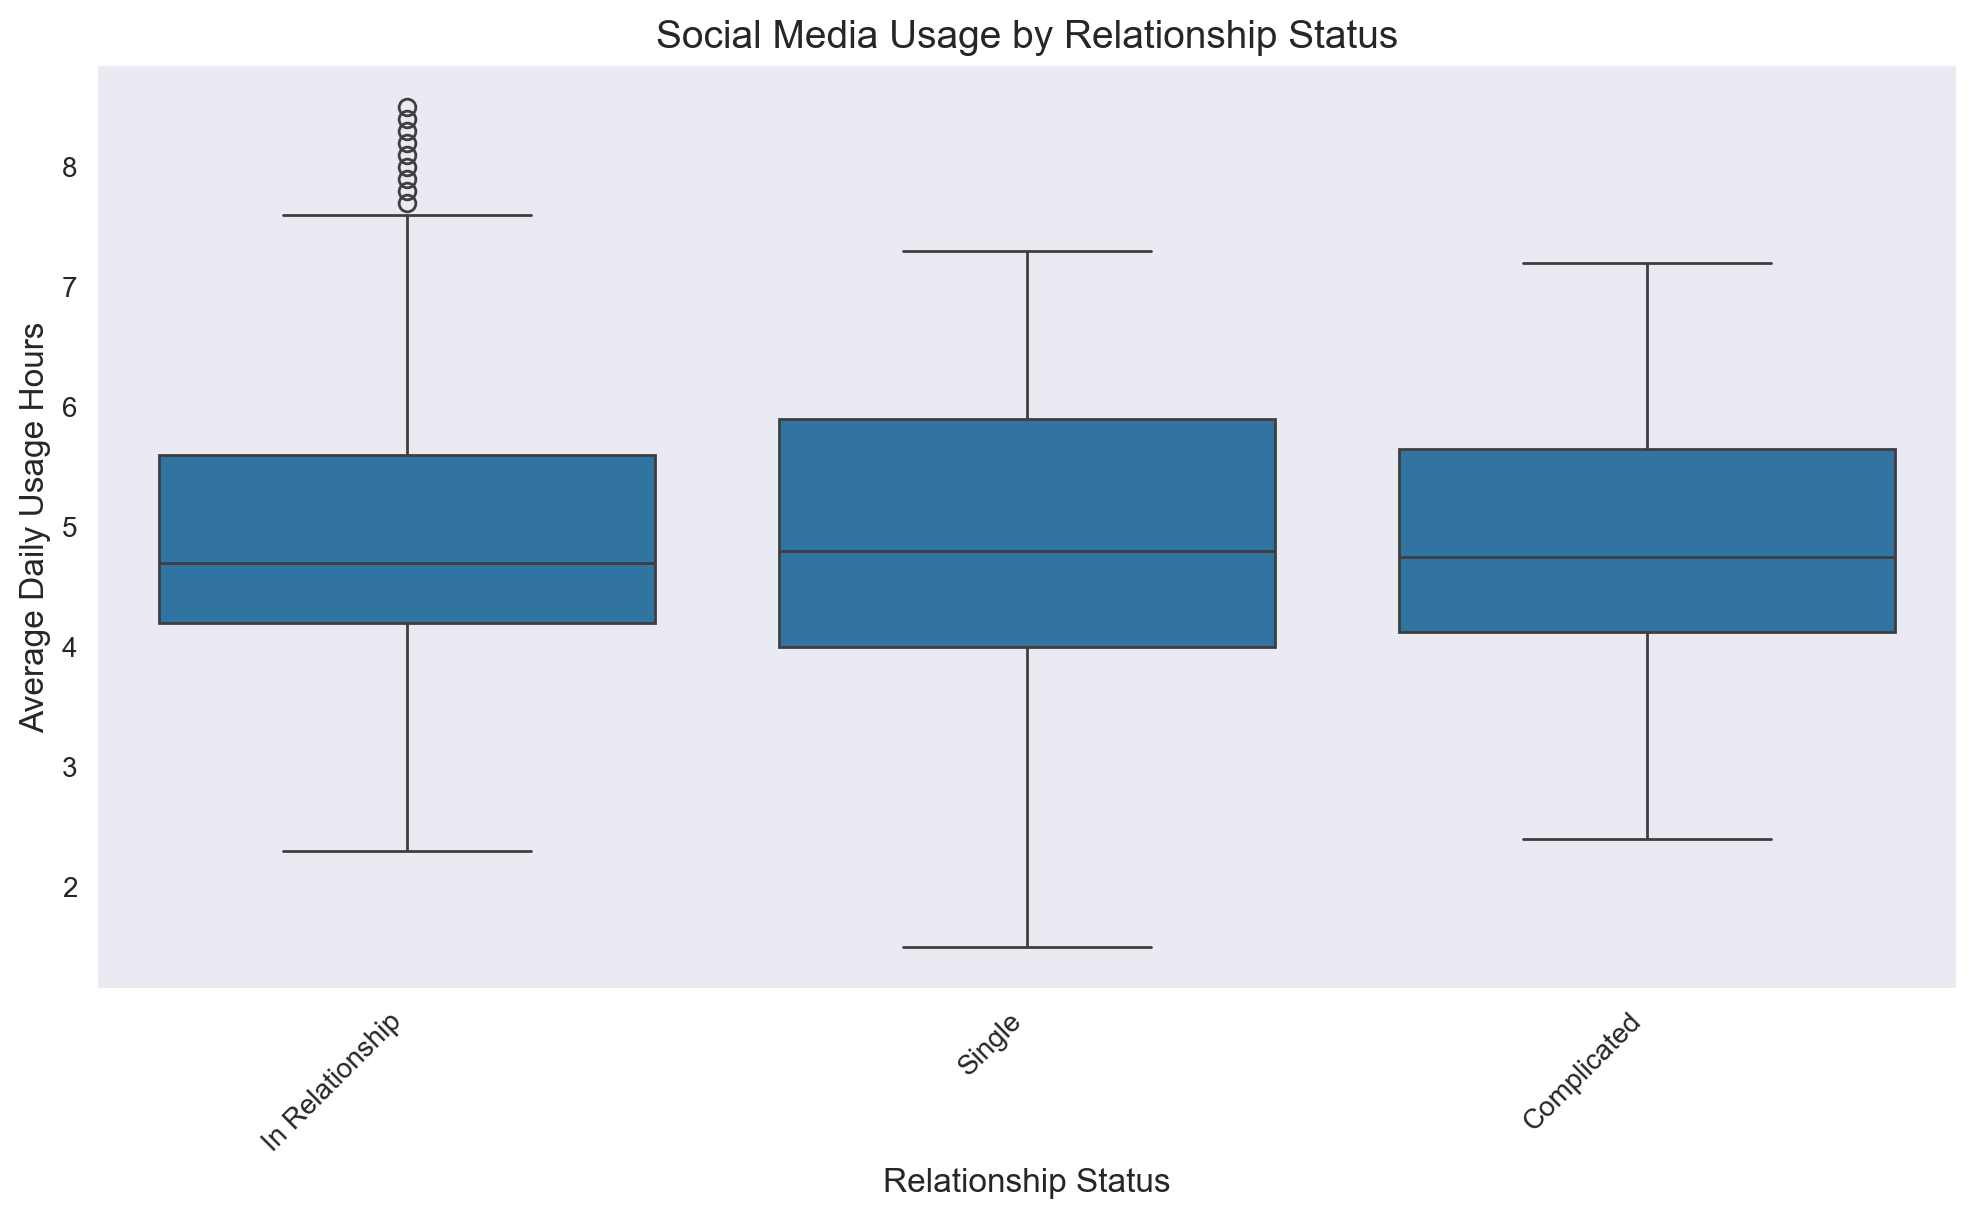

In [104]:
# #### Relationship Status vs Social Media Usage
plt.figure(figsize=(12, 6))
sns.boxplot(x='Relationship_Status', y='Avg_Daily_Usage_Hours', data=df)
plt.title('Social Media Usage by Relationship Status', fontsize=14)
plt.xlabel('Relationship Status', fontsize=12)
plt.ylabel('Average Daily Usage Hours', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.show()

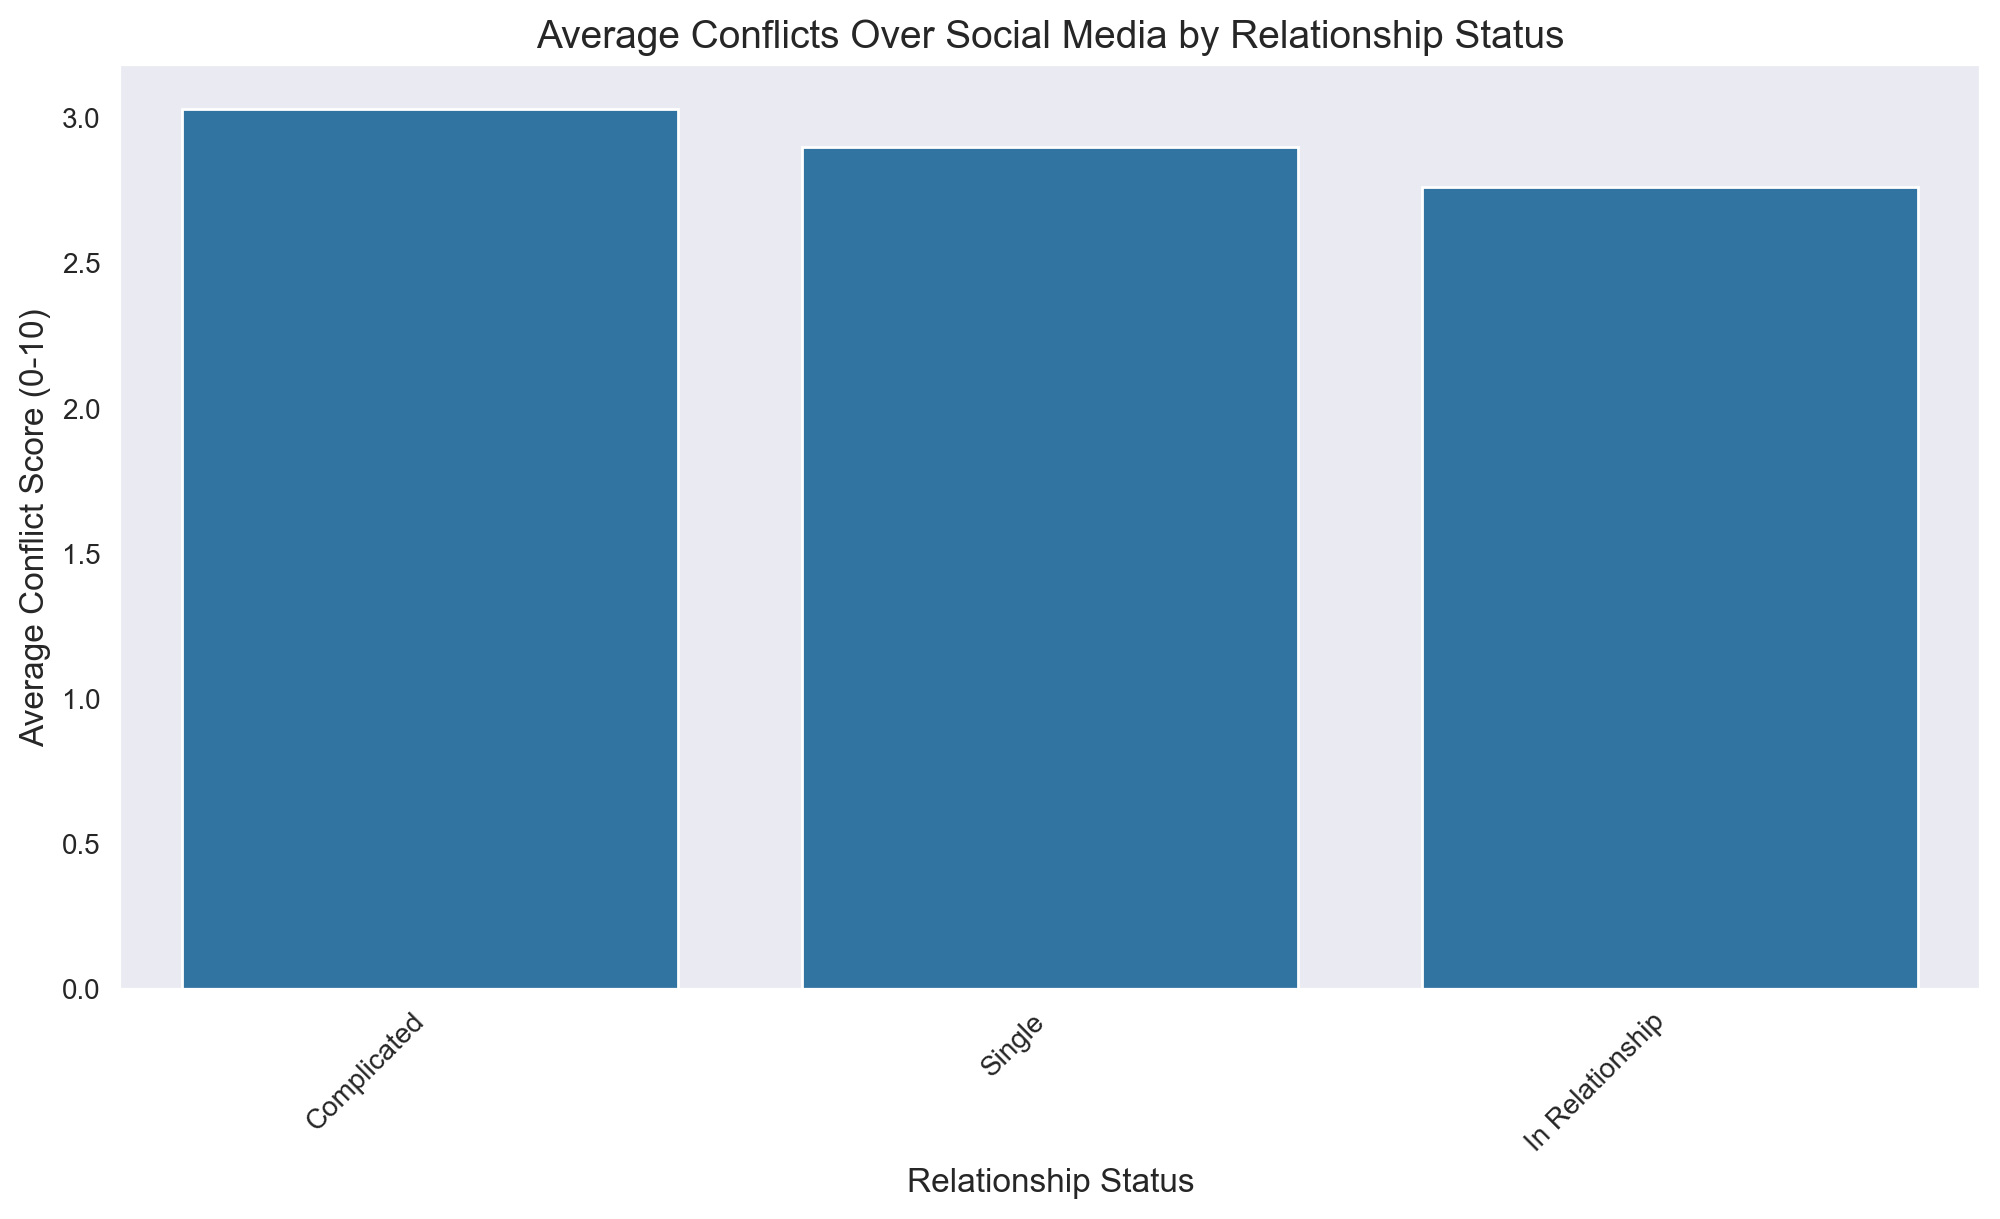

In [105]:
# #### Conflicts Over Social Media by Relationship Status
relationship_conflicts = df.groupby('Relationship_Status')['Conflicts_Over_Social_Media'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=relationship_conflicts.index, y=relationship_conflicts.values)
plt.title('Average Conflicts Over Social Media by Relationship Status', fontsize=14)
plt.xlabel('Relationship Status', fontsize=12)
plt.ylabel('Average Conflict Score (0-10)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.show()

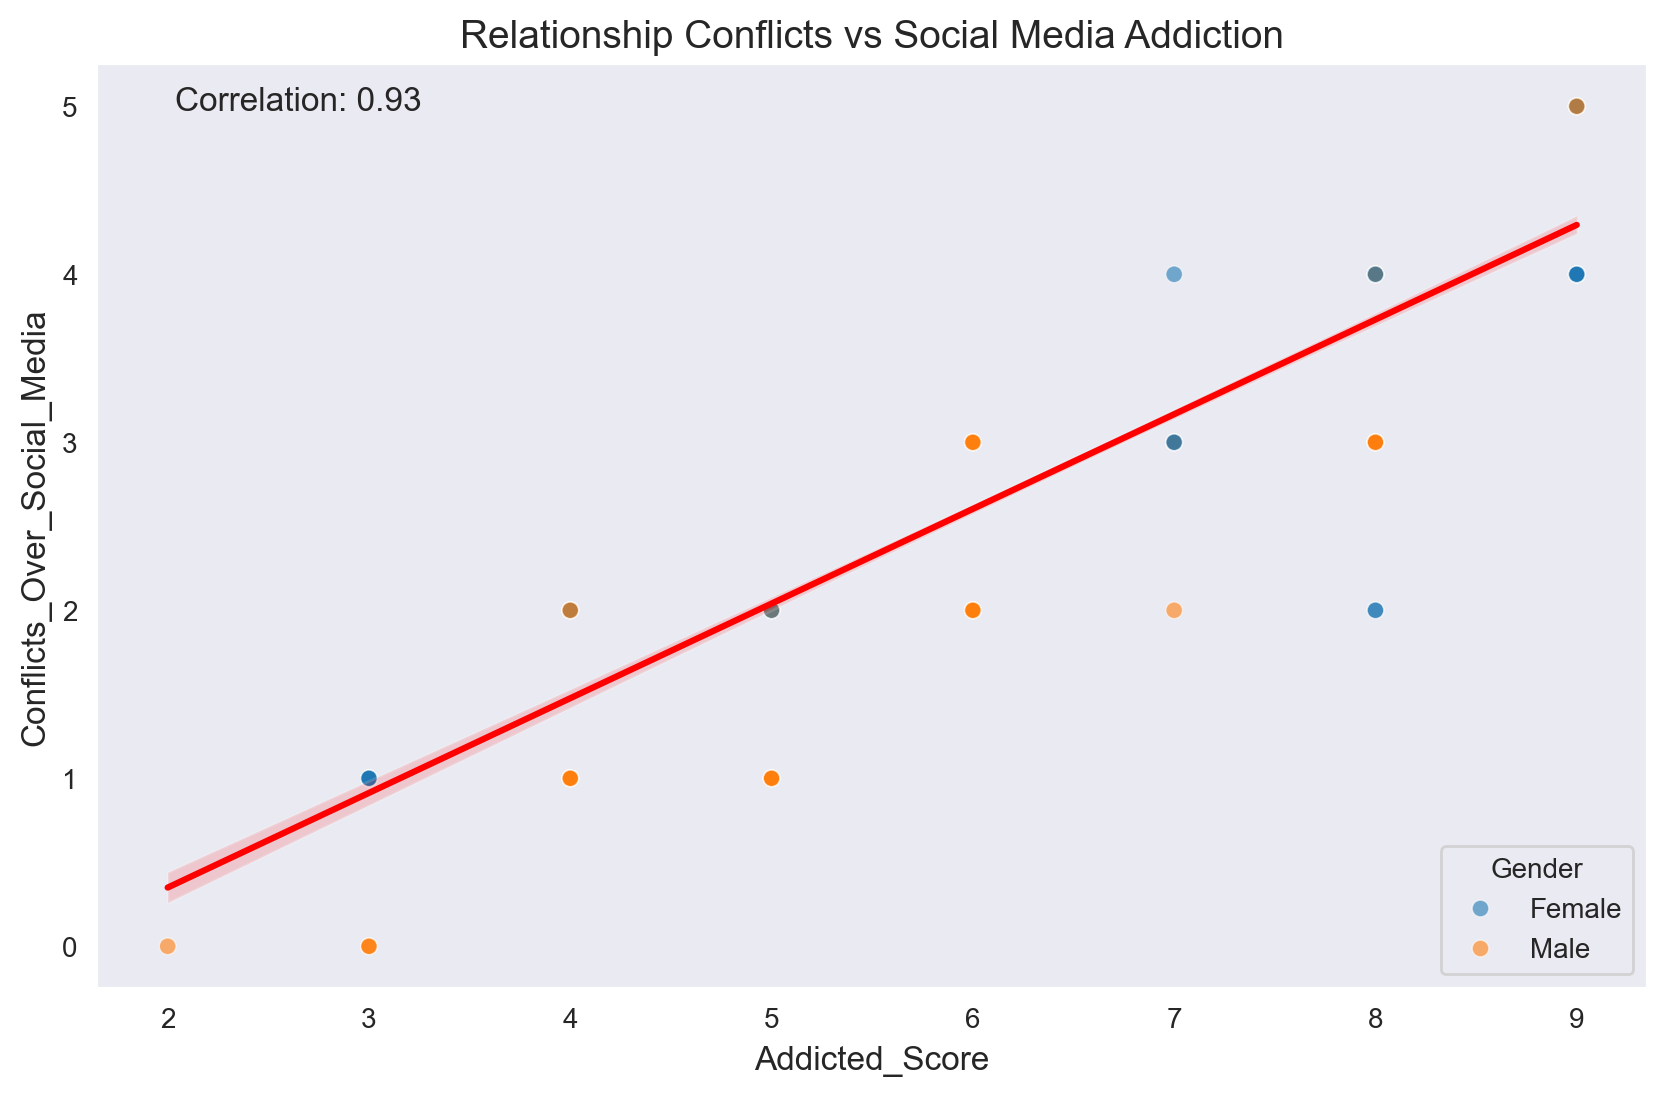

In [106]:
# #### Social Media Addiction vs Relationship Conflicts
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Addicted_Score', y='Conflicts_Over_Social_Media', data=df, alpha=0.6, hue='Gender')
plt.title('Relationship Conflicts vs Social Media Addiction', fontsize=14)
plt.xlabel('Addiction Score (0-10)', fontsize=12)
plt.ylabel('Conflicts Over Social Media (0-10)', fontsize=12)

# Add regression line
sns.regplot(x='Addicted_Score', y='Conflicts_Over_Social_Media', data=df, scatter=False, color='red')

# Calculate correlation
correlation = df['Addicted_Score'].corr(df['Conflicts_Over_Social_Media'])
plt.annotate(f'Correlation: {correlation:.2f}', xy=(0.05, 0.95), xycoords='axes fraction', fontsize=12)

plt.show()

#### 6. Interactive Visualizations with Plotly|

In [108]:
import plotly.express as px

fig = px.scatter(
    df,
    x='Avg_Daily_Usage_Hours',
    y='Addicted_Score',   # safer than Mental_Health_Score
    color='Sleep_Category',   # ONLY if you created it earlier
    size='Addicted_Score',
    hover_name='Country',
    hover_data=['Age', 'Gender', 'Academic_Level', 'Most_Used_Platform'],
    title='Social Media Usage vs Addiction vs Sleep Quality'
)

fig.update_layout(width=900, height=600)
fig.show()

In [110]:
platform_by_age = pd.crosstab(df['Age'], df['Most_Used_Platform'])

In [111]:
platform_by_age_percentage = platform_by_age.div(platform_by_age.sum(axis=1), axis=0) * 100

In [112]:
import pandas as pd
import plotly.graph_objects as go

platform_by_age = pd.crosstab(df['Age'], df['Most_Used_Platform'])
platform_by_age_percentage = platform_by_age.div(platform_by_age.sum(axis=1), axis=0) * 100

fig = go.Figure()

for platform in platform_by_age_percentage.columns:
    fig.add_trace(go.Bar(
        x=platform_by_age_percentage.index,
        y=platform_by_age_percentage[platform],
        name=platform
    ))

fig.update_layout(
    barmode='stack',
    title='Platform Popularity by Age',
    xaxis_title='Age',
    yaxis_title='Percentage',
    width=900,
    height=600
)

fig.show()

In [113]:
# #### Interactive Heatmap: Correlation Matrix
corr_matrix = df[['Age', 'Avg_Daily_Usage_Hours', 'Sleep_Hours_Per_Night', 
                  'Mental_Health_Score', 'Conflicts_Over_Social_Media', 'Addicted_Score']].corr()

fig = px.imshow(corr_matrix, 
                text_auto=True, 
                aspect="auto", 
                color_continuous_scale='viridis')
fig.update_layout(
    title='Correlation Matrix of Key Variables',
    width=800,
    height=700
)
fig.show()

### Research Questions

In [5]:
import sys
!{sys.executable} -m pip install statsmodels scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 21.2 MB/s  0:00:00eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 16.6 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [statsmodels] [statsmodels]]

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip


In [10]:
# Create a linear regression model with 'age' as the independent variable and 'cholesterol' as the dependent variable
# Use the statsmodels package to fit an ordinary least squares (OLS) regresesion model 
X = df['age']
y = df['cholesterol']
X_with_const = sm.add_constant(X)
model_sm = sm.OLS(y, X_with_const).fit()

NameError: name 'df' is not defined

In [20]:
import pandas as pd

df = pd.read_csv("Students_Social_Media_Addiction 2.csv")
df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'Students_Social_Media_Addiction 2.csv'

In [16]:
# Recreate the scatter plot of age verus cholesterol and add the line of best fit from the OLS regression model
sns.scatterplot(x='age', y='cholesterol', data=df)
plt.plot(X, model_sm.fittedvalues, color='red')
plt.title('Scatter Plot of Age vs. Cholesterol with OLS Line of Best Fit')
plt.xlabel('Age')       
plt.ylabel('Cholesterol')
plt.show()


NameError: name 'df' is not defined